In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
import joblib
from sklearn.inspection import permutation_importance
import seaborn as sns

/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/ENV/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ALLOW_FUTURE_VALIDATION = True  

# Pre-Processing

### DATA LOADING

In [3]:
Data = pd.read_excel("/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/data/Company Data.xlsx")
Data.to_csv("/Users/dhanujiamanda/Documents/Projects/Agentic AI /Pipeline/Agentic-AI-for-Pharma-Stockout-Problem/data/Company Data.csv", index=False)

In [4]:
# To delete incomplete month
Data = Data[~((Data["Year"] == 2026) & (Data["Month_Number"] == 2))].copy()

Data = Data.sort_values(["ItemCode", "Year", "Month_Number"]).reset_index(drop=True)

# Clean raw negatives
for c in [
    "Secondary_Sales_Qty",
    "Primary_Sales_Qty",
    "Free_Qty",
    "Available_Primary_Inventory_Qty",
    "Distributor_Inventory_Qty",
    "Blocked_Stock_Qty",
    "Inspection_Stock_Qty",
    "Total_Primary_Inventory_Qty"
]:
    if c in Data.columns:
        Data[c] = Data[c].clip(lower=0)

# Base observed movement
Data["Observed_Demand"] = Data["Secondary_Sales_Qty"].clip(lower=0)

In [5]:
print(Data.info())
print(Data.head(5))
print(Data.count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146603 entries, 0 to 146602
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Month                            146603 non-null  object 
 1   Year                             146603 non-null  int64  
 2   Month_Number                     146603 non-null  int64  
 3   ItemCode                         146603 non-null  int64  
 4   Secondary_Sales_Qty              146603 non-null  float64
 5   Free_Qty                         146603 non-null  float64
 6   Primary_Sales_Qty                146603 non-null  float64
 7   Available_Primary_Inventory_Qty  146603 non-null  float64
 8   Blocked_Stock_Qty                146603 non-null  float64
 9   Inspection_Stock_Qty             146603 non-null  float64
 10  Total_Primary_Inventory_Qty      146603 non-null  float64
 11  Distributor_Inventory_Qty        146603 non-null  int64  
 12  Bo

### DATA QUALITY CHECKS

In [6]:
# Check Duplicates
dup_count = Data.duplicated().sum()
print(dup_count)

# Check Nulls
null_count = Data.isnull().sum()
print("Nulls:\n", null_count)

0
Nulls:
 Month                              0
Year                               0
Month_Number                       0
ItemCode                           0
Secondary_Sales_Qty                0
Free_Qty                           0
Primary_Sales_Qty                  0
Available_Primary_Inventory_Qty    0
Blocked_Stock_Qty                  0
Inspection_Stock_Qty               0
Total_Primary_Inventory_Qty        0
Distributor_Inventory_Qty          0
Bonus_Flag                         0
Supply_Constraint_Flag             0
Distributor_Buffer_Flag            0
Time_Index                         0
Observed_Demand                    0
dtype: int64


### DEMAND SIGNAL CONSTRUCTION

In [7]:
# =========================
# PAST-ONLY HELPER FEATURES
# =========================
grp = Data.groupby("ItemCode")

# Lag demand
Data["Lag1_Obs"] = grp["Observed_Demand"].shift(1)
Data["Lag2_Obs"] = grp["Observed_Demand"].shift(2)
Data["Lag3_Obs"] = grp["Observed_Demand"].shift(3)
Data["Lag6_Obs"] = grp["Observed_Demand"].shift(6)
Data["Lag12_Obs"] = grp["Observed_Demand"].shift(12)

# Rolling stats from observed demand
Data["Rolling3M_Obs_Mean"] = grp["Observed_Demand"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
Data["Rolling6M_Obs_Mean"] = grp["Observed_Demand"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
Data["Rolling3M_Obs_Std"] = grp["Observed_Demand"].transform(lambda x: x.rolling(3, min_periods=1).std().shift(1)).fillna(0)

# Safe baseline
Data["Baseline_Demand"] = Data["Rolling3M_Obs_Mean"].fillna(Data["Lag1_Obs"]).fillna(0)

# Uplift ratio
Data["Uplift_vs_Baseline"] = np.where(
    Data["Baseline_Demand"] <= 0,
    1.0,
    Data["Observed_Demand"] / (Data["Baseline_Demand"] + 1)
)

# Z-score past-only
Data["Z_Score_Obs"] = (
    (Data["Observed_Demand"] - Data["Rolling3M_Obs_Mean"]) /
    (Data["Rolling3M_Obs_Std"] + 1)
).fillna(0)

In [8]:
# =========================
# RECURRING BONUS SKU DETECTION
# =========================
def detect_recurring_bonus_skus(df,
                                min_bonus_months=3,
                                gap_tolerance=1,
                                uplift_threshold=1.4):
    """
    Detect SKUs where bonus months happen in a stable repeated interval
    and those months consistently create strong uplift.
    """
    out = []

    for item, g in df.groupby("ItemCode"):
        g = g.sort_values(["Year", "Month_Number"]).copy()
        g["Time_Index"] = np.arange(len(g))

        bonus_rows = g[g["Bonus_Flag"] == 1].copy()

        recurring_flag = 0
        cycle_len = 0
        avg_gap = np.nan
        bonus_freq_12m = 0.0
        avg_bonus_uplift = 1.0

        if len(g) > 0:
            bonus_freq_12m = bonus_rows.shape[0] / len(g)

        if len(bonus_rows) >= min_bonus_months:
            gaps = bonus_rows["Time_Index"].diff().dropna()

            if len(gaps) > 0:
                avg_gap = gaps.mean()

                rounded_gap = int(round(avg_gap))
                stable_gap = ((gaps - rounded_gap).abs() <= gap_tolerance).mean()

                avg_bonus_uplift = bonus_rows["Uplift_vs_Baseline"].replace([np.inf, -np.inf], np.nan).clip(0,5).fillna(1.0).mean()

                # recurring if gaps are stable and uplift is meaningful
                if stable_gap >= 0.6 and avg_bonus_uplift >= uplift_threshold:
                    recurring_flag = 1
                    cycle_len = rounded_gap

        out.append({
            "ItemCode": item,
            "Recurring_Bonus_SKU": recurring_flag,
            "Bonus_Cycle_Length": cycle_len,
            "Avg_Bonus_Gap": avg_gap if pd.notna(avg_gap) else 0,
            "Bonus_Frequency_All": bonus_freq_12m,
            "Avg_Bonus_Uplift": avg_bonus_uplift
        })

    return pd.DataFrame(out)

In [9]:
# Placeholder for now
for c in ["Recurring_Bonus_SKU","Bonus_Cycle_Length","Avg_Bonus_Gap","Bonus_Frequency_All"]:
    Data[c] = 0

Data["Avg_Bonus_Uplift"] = 1.0

for c in ["Months_Since_Last_Bonus",
    "Expected_Bonus_Month",
    "Expected_Bonus_NextMonth",
    "Post_Bonus_NextMonth_Flag",
    "Bonus_Flag_Lag1",
    "Bonus_Flag_Lag2",
    "Bonus_Flag_Lag3",
    "Bonus_Frequency_12M"
]:
    Data[c] = 0

In [10]:
# =========================
# BONUS CYCLE FEATURES
# =========================
def add_bonus_cycle_features(df):
    df = df.sort_values(["ItemCode", "Year", "Month_Number"]).copy()

    pieces = []

    for item_code, g in df.groupby("ItemCode", sort=False):
        g = g.sort_values(["Year", "Month_Number"]).copy()

        # make absolutely sure ItemCode exists as a column
        g["ItemCode"] = item_code

        bonus_positions = np.where(g["Bonus_Flag"].values == 1)[0]

        months_since_last_bonus = []
        expected_bonus_this_month = []

        for i in range(len(g)):
            past_bonus = bonus_positions[bonus_positions < i]

            if len(past_bonus) == 0:
                months_since_last_bonus.append(999)
            else:
                months_since_last_bonus.append(i - past_bonus[-1])

            cyc = g["Bonus_Cycle_Length"].iloc[i]
            recurring = g["Recurring_Bonus_SKU"].iloc[i]

            if recurring == 1 and cyc > 0 and len(past_bonus) > 0:
                expected_bonus_this_month.append(
                    1 if abs((i - past_bonus[-1]) - cyc) <= 1 else 0
                )
            else:
                expected_bonus_this_month.append(0)

        g["Months_Since_Last_Bonus"] = months_since_last_bonus
        g["Expected_Bonus_Month"] = expected_bonus_this_month

        g["Bonus_Flag_Lag1"] = g["Bonus_Flag"].shift(1).fillna(0)
        g["Bonus_Flag_Lag2"] = g["Bonus_Flag"].shift(2).fillna(0)
        g["Bonus_Flag_Lag3"] = g["Bonus_Flag"].shift(3).fillna(0)

        g["Bonus_Frequency_12M"] = (
            g["Bonus_Flag"]
            .rolling(12, min_periods=1)
            .mean()
            .shift(1)
            .fillna(0)
        )

        pieces.append(g)

    out = pd.concat(pieces, axis=0, ignore_index=True)
    return out

In [11]:
# =========================
# CHANNEL / STOCK FLOW FEATURES
# =========================
Data["Net_Available_Stock"] = (
    Data["Total_Primary_Inventory_Qty"]
    - Data["Blocked_Stock_Qty"]
    - Data["Inspection_Stock_Qty"]
).clip(lower=0)

Data["Primary_Stock_Cover"] = np.where(
    Data["Baseline_Demand"] <= 0,
    0,
    Data["Net_Available_Stock"] / (Data["Baseline_Demand"] + 1)
)

Data["Distributor_Stock_Cover"] = np.where(
    Data["Baseline_Demand"] <= 0,
    0,
    Data["Distributor_Inventory_Qty"] / (Data["Baseline_Demand"] + 1)
)

Data["Primary_to_Distributor_Ratio"] = np.where(
    Data["Distributor_Inventory_Qty"] <= 0,
    0,
    Data["Net_Available_Stock"] / (Data["Distributor_Inventory_Qty"] + 1)
)

Data["Blocked_Stock_Ratio"] = np.where(
    Data["Total_Primary_Inventory_Qty"] <= 0,
    0,
    Data["Blocked_Stock_Qty"] / (Data["Total_Primary_Inventory_Qty"] + 1)
)

Data["Inspection_Stock_Ratio"] = np.where(
    Data["Total_Primary_Inventory_Qty"] <= 0,
    0,
    Data["Inspection_Stock_Qty"] / (Data["Total_Primary_Inventory_Qty"] + 1)
)

Data["Primary_Inv_Change"] = Data.groupby("ItemCode")["Net_Available_Stock"].diff().fillna(0)
Data["Distributor_Inv_Change"] = Data.groupby("ItemCode")["Distributor_Inventory_Qty"].diff().fillna(0)

Data["Primary_to_Distributor_Ratio"] = Data["Primary_to_Distributor_Ratio"].clip(upper=Data["Primary_to_Distributor_Ratio"].quantile(0.99))

Data["Distributor_Inv_Change"] = Data["Distributor_Inv_Change"].clip(upper=Data["Distributor_Inv_Change"].quantile(0.99))
Data["Primary_Inv_Change"] = Data["Primary_Inv_Change"].clip(upper=Data["Primary_Inv_Change"].quantile(0.99))


### BUSINESS RULE ADJUSTMENTS

In [12]:
Data["Effective_Demand"] = Data["Observed_Demand"].copy()

In [13]:
# ─── RULE: Supply-constraint correction ────────────────────────────────────────────────── 

Data["Supply_Baseline"] = Data["Rolling3M_Obs_Mean"].fillna(Data["Lag1_Obs"]).fillna(Data["Observed_Demand"])

supply_constrained = (Data["Supply_Constraint_Flag"] == 1)

Data["Effective_Demand"] = np.where(
    supply_constrained,
    np.maximum(Data["Observed_Demand"], 0.85 * Data["Supply_Baseline"]),
    Data["Effective_Demand"]
)

'''
If supply was constrained (stock not available), observed sales may be artificially low.
So we cap demand to a safer value: last 3-month average secondary sales (shifted to avoid leakage).

If Supply_Constraint_Flag == 1:
   Effective_Demand = min(current sales, rolling average)
Else:
   keep current demand

if constrained, observed sales may be lower than true pull.
Instead of min(current, rolling), use max(current, a safe baseline fraction)
'''

'\nIf supply was constrained (stock not available), observed sales may be artificially low.\nSo we cap demand to a safer value: last 3-month average secondary sales (shifted to avoid leakage).\n\nIf Supply_Constraint_Flag == 1:\n   Effective_Demand = min(current sales, rolling average)\nElse:\n   keep current demand\n\nif constrained, observed sales may be lower than true pull.\nInstead of min(current, rolling), use max(current, a safe baseline fraction)\n'

In [14]:
# ─── RULE: Irregular bonus spike detection via Z-score ────────────────────────────────────────────────── 

irregular_bonus_spike = (
    (Data["Bonus_Flag"] == 1) &
    (Data["Recurring_Bonus_SKU"] == 0) &
    (Data["Z_Score_Obs"] > 2.0) &
    (Data["Uplift_vs_Baseline"] > 1.6)
)
'''
High Z-score means current demand is unusually higher than its recent baseline.
+1 in denominator prevents division exploding for stable/low-variance SKUs.
'''

'\nHigh Z-score means current demand is unusually higher than its recent baseline.\n+1 in denominator prevents division exploding for stable/low-variance SKUs.\n'

In [15]:
# ─── RULE: Stockout-like demand suppression (past-only) ────────────────────────────────────────────────── 

prev_obs = grp["Observed_Demand"].shift(1)
prev_primary_cover = grp["Primary_Stock_Cover"].shift(1)
prev_dist_cover = grp["Distributor_Stock_Cover"].shift(1)

stockout_drop_condition = (
    (Data["Observed_Demand"] < 0.65 * prev_obs.fillna(Data["Observed_Demand"])) &
    (Data["Supply_Constraint_Flag"] == 1) &
    (
        (prev_primary_cover.fillna(99) < 1.0) |
        (prev_dist_cover.fillna(99) < 1.0)
    )
)

In [16]:
# Start clean demand
Data["Clean_Demand"] = Data["Effective_Demand"].copy()

# For irregular bonus spikes: smooth partially
Data.loc[irregular_bonus_spike, "Clean_Demand"] = (
    0.60 * Data.loc[irregular_bonus_spike, "Observed_Demand"] +
    0.40 * Data.loc[irregular_bonus_spike, "Baseline_Demand"]
)

# For stockout-like drop: normalize upward toward baseline
Data.loc[stockout_drop_condition, "Clean_Demand"] = np.maximum(
    Data.loc[stockout_drop_condition, "Observed_Demand"],
    0.90 * Data.loc[stockout_drop_condition, "Baseline_Demand"]
)

Data["Clean_Demand"] = Data["Clean_Demand"].clip(lower=0)

# Flags for model
Data["Bonus_Shock"] = irregular_bonus_spike.astype(int)
Data["Recurring_Bonus_Month"] = 0
Data["Supply_Shock"] = stockout_drop_condition.astype(int)

# PROMO INTENSITY FEATURES
Data["Free_Ratio"] = np.where(
    Data["Primary_Sales_Qty"] <= 0,
    0,
    Data["Free_Qty"] / (Data["Primary_Sales_Qty"] + 1)
)

grp = Data.groupby("ItemCode")

### SAVE BASE DATASET

In [17]:
Base_Data = Data.copy()

In [18]:
Data.to_csv("base_cleaned_data.csv", index=False)

# Modelling

### MODEL FEATURE ENGINEERING

#### Core Config

In [19]:
TARGET_COL = "Target"

#### Helper Functions

##### Other

In [20]:
def sanitize(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df.fillna(0)

def recency_weights(df, yearly_boost=0.25, base=1.0):
    y0 = df["Year"].min()
    return base + (df["Year"] - y0) * yearly_boost

def wmape(y_true, y_pred):
    denominator = np.sum(y_true)
    if denominator == 0:
        return 0
    return np.sum(np.abs(y_true - y_pred)) / denominator * 100

def forecast_bias(y_true, y_pred):
    denominator = np.sum(y_true)
    if denominator == 0:
        return 0
    return np.sum(y_pred - y_true) / denominator * 100

def recompute_target(df):
    df = df.copy()
    df[TARGET_COL] = df.groupby("ItemCode")["Clean_Demand"].shift(-1)
    return df

def compute_clip_caps(train_df, cols, q=0.99):
    """Compute clipping caps using TRAIN only."""
    caps = {}
    for c in cols:
        if c in train_df.columns:
            caps[c] = float(train_df[c].replace([np.inf, -np.inf], np.nan).dropna().quantile(q))
    return caps

def apply_clip_caps(df, caps):
    """Apply previously computed caps to any df."""
    df = df.copy()
    for c, cap in caps.items():
        if c in df.columns:
            df[c] = df[c].clip(upper=cap)
    return df

def assert_features_exist(df, feature_cols, where=""):
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{where}] Missing required features: {missing}")

def underforecast_rate(y_true, y_pred):
    diff = y_true - y_pred
    under = np.where(diff > 0, diff, 0)
    denom = np.sum(y_true)
    if denom == 0:
        return 0
    return np.sum(under) / denom * 100

def evaluate_all_metrics(y_true, y_pred):
    return {
        "WMAPE": wmape(y_true, y_pred),
        "Bias": forecast_bias(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Underforecast_Rate": underforecast_rate(y_true, y_pred)
    }

In [21]:
# Rebuild Time Features

def rebuild_time_features(df):
    df = df.sort_values(["ItemCode", "Year", "Month_Number"]).copy()
    grp = df.groupby("ItemCode")

    for lag in [1, 2, 3, 6, 12]:
        df[f"Lag{lag}"] = grp["Clean_Demand"].shift(lag)

    df["Rolling3M_Mean"] = grp["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
    df["Rolling6M_Mean"] = grp["Clean_Demand"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
    df["Rolling3M_Std"] = grp["Clean_Demand"].transform(lambda x: x.rolling(3, min_periods=1).std().shift(1)).fillna(0)
    df["Rolling3M_Std"] = df["Rolling3M_Std"].clip(upper=df["Rolling3M_Std"].quantile(0.99))

    df["Month_Sin"] = np.sin(2 * np.pi * df["Month_Number"] / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * df["Month_Number"] / 12)

    df["Momentum"] = df["Lag1"] - df["Lag3"]

    df["Is_Zero"] = (df["Clean_Demand"] == 0).astype(int)
    df["ZeroRate_6M"] = grp["Is_Zero"].transform(
        lambda x: x.rolling(6, min_periods=1).mean().shift(1)
    ).fillna(0)

    df["Inventory_Pressure"] = np.where(
        df["Lag1"].fillna(0) == 0,
        0,
        df["Available_Primary_Inventory_Qty"] / (df["Lag1"] + 1)
    )
    df["Inventory_Pressure"] = df["Inventory_Pressure"].clip(
        upper=df["Inventory_Pressure"].quantile(0.99)
    )

    df["Net_Available_Stock"] = (
        df["Total_Primary_Inventory_Qty"]
        - df["Blocked_Stock_Qty"]
        - df["Inspection_Stock_Qty"]
    ).clip(lower=0)

    df["Stock_Cover_Months"] = np.where(
        df["Rolling3M_Mean"].fillna(0) == 0,
        0,
        df["Net_Available_Stock"] / (df["Rolling3M_Mean"] + 1)
    )
    df["Stock_Cover_Months"] = pd.Series(df["Stock_Cover_Months"], index=df.index).clip(
        upper=pd.Series(df["Stock_Cover_Months"], index=df.index).quantile(0.99)
    )

    df["Primary_Stock_Cover"] = np.where(
        df["Rolling3M_Mean"].fillna(0) == 0,
        0,
        df["Net_Available_Stock"] / (df["Rolling3M_Mean"] + 1)
    )

    df["Distributor_Stock_Cover"] = np.where(
        df["Rolling3M_Mean"].fillna(0) == 0,
        0,
        df["Distributor_Inventory_Qty"] / (df["Rolling3M_Mean"] + 1)
    )

    df["Supply_Constraint_Lag1"] = grp["Supply_Constraint_Flag"].shift(1).fillna(0)
    df["Supply_Constraint_Lag2"] = grp["Supply_Constraint_Flag"].shift(2).fillna(0)

    df["Primary_Stock_Cover_Lag1"] = grp["Primary_Stock_Cover"].shift(1).fillna(0)
    df["Distributor_Stock_Cover_Lag1"] = grp["Distributor_Stock_Cover"].shift(1).fillna(0)

    df["Free_Qty_Lag1"] = grp["Free_Qty"].shift(1).fillna(0)
    df["Free_Ratio_Lag1"] = grp["Free_Ratio"].shift(1).fillna(0)

    df["Primary_to_Distributor_Ratio"] = np.where(
        df["Distributor_Inventory_Qty"] <= 0,
        0,
        df["Net_Available_Stock"] / (df["Distributor_Inventory_Qty"] + 1)
    )

    df["Blocked_Stock_Ratio"] = np.where(
        df["Total_Primary_Inventory_Qty"] <= 0,
        0,
        df["Blocked_Stock_Qty"] / (df["Total_Primary_Inventory_Qty"] + 1)
    )

    df["Inspection_Stock_Ratio"] = np.where(
        df["Total_Primary_Inventory_Qty"] <= 0,
        0,
        df["Inspection_Stock_Qty"] / (df["Total_Primary_Inventory_Qty"] + 1)
    )

    df["Primary_Inv_Change"] = df.groupby("ItemCode")["Net_Available_Stock"].diff().fillna(0)
    df["Distributor_Inv_Change"] = df.groupby("ItemCode")["Distributor_Inventory_Qty"].diff().fillna(0)

    df["Primary_to_Distributor_Ratio"] = df["Primary_to_Distributor_Ratio"].clip(upper=df["Primary_to_Distributor_Ratio"].quantile(0.99))
    df["Distributor_Inv_Change"] = df["Distributor_Inv_Change"].clip(upper=df["Distributor_Inv_Change"].quantile(0.99))
    df["Primary_Inv_Change"] = df["Primary_Inv_Change"].clip(upper=df["Primary_Inv_Change"].quantile(0.99))

    # bonus history
    df["Bonus_Flag_Lag1"] = grp["Bonus_Flag"].shift(1).fillna(0)
    df["Bonus_Flag_Lag2"] = grp["Bonus_Flag"].shift(2).fillna(0)
    df["Bonus_Flag_Lag3"] = grp["Bonus_Flag"].shift(3).fillna(0)
    df["Bonus_Frequency_12M"] = grp["Bonus_Flag"].transform(
        lambda x: x.rolling(12, min_periods=1).mean().shift(1)
    ).fillna(0)

    # months since last bonus
    def _months_since_last_bonus(g):
        pos = np.where(g["Bonus_Flag"].values == 1)[0]
        out = []
        for i in range(len(g)):
            past = pos[pos < i]
            out.append(999 if len(past) == 0 else i - past[-1])
        return pd.Series(out, index=g.index)

    months_since = []
    for _, g in df.groupby("ItemCode", sort=False):
        pos = np.where(g["Bonus_Flag"].values == 1)[0]
        out = []
        for i in range(len(g)):
            past = pos[pos < i]
            out.append(999 if len(past) == 0 else i - past[-1])
        months_since.extend(out)
    df["Months_Since_Last_Bonus"] = months_since

    df["Expected_Bonus_Month"] = np.where(
        (df["Recurring_Bonus_SKU"] == 1) &
        (df["Bonus_Cycle_Length"] > 0) &
        (np.abs(df["Months_Since_Last_Bonus"] - df["Bonus_Cycle_Length"]) <= 1),
        1, 0
    )

    df["Expected_Bonus_NextMonth"] = np.where(
        (df["Recurring_Bonus_SKU"] == 1) &
        (df["Bonus_Cycle_Length"] > 0) &
        (np.abs((df["Months_Since_Last_Bonus"] + 1) - df["Bonus_Cycle_Length"]) <= 1),
        1, 0
    )

    df["Post_Bonus_NextMonth_Flag"] = ((df["Bonus_Flag"] == 1) | (df["Expected_Bonus_Month"] == 1)).astype(int)

    # Prom Block
    df["Realized_Uplift"] = np.where(
        df["Rolling3M_Mean"].fillna(0) <= 0,
        1.0,
        df["Clean_Demand"] / (df["Rolling3M_Mean"] + 1)
    )
    df["Realized_Uplift"] = df["Realized_Uplift"].clip(0, 6)

    df["Bonus_Demand_Only"] = np.where(
    df["Bonus_Flag"] == 1,df["Clean_Demand"],np.nan)

    grp2 = df.groupby("ItemCode")
    df["Promo_Uplift_Lag1"] = grp2["Realized_Uplift"].shift(1).fillna(1.0)
    df["Promo_Uplift_Lag2"] = grp2["Realized_Uplift"].shift(2).fillna(1.0)
    df["Promo_Uplift_6M"] = grp2["Realized_Uplift"].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1)).fillna(1.0)

    df["Last_Bonus_Demand"] = (grp2["Bonus_Demand_Only"].transform(lambda x: x.shift(1).ffill()).fillna(0))
    df["Bonus_Sin"] = df["Bonus_Flag"] * np.sin(2 * np.pi * df["Month_Number"] / 12)
    df["Bonus_Cos"] = df["Bonus_Flag"] * np.cos(2 * np.pi * df["Month_Number"] / 12)

    sku_stats = df.groupby("ItemCode").agg(
        SKU_Mean_Demand=("Clean_Demand","mean"),
        SKU_Std_Demand=("Clean_Demand","std"),
        SKU_Max_Demand=("Clean_Demand","max"),
        SKU_ZeroRate=("Is_Zero","mean"),
        SKU_BonusRate=("Bonus_Flag","mean"),
        SKU_SupplyConstraintRate=("Supply_Constraint_Flag","mean")
    ).reset_index()

    sku_stats["SKU_CV"] = np.where(
        sku_stats["SKU_Mean_Demand"] <= 0,
        0,
        sku_stats["SKU_Std_Demand"].fillna(0) /
        (sku_stats["SKU_Mean_Demand"] + 1)
    )

    df = df.drop(columns=[
        "SKU_Mean_Demand",
        "SKU_Std_Demand",
        "SKU_Max_Demand",
        "SKU_ZeroRate",
        "SKU_BonusRate",
        "SKU_SupplyConstraintRate",
        "SKU_CV"
    ], errors="ignore")

    df = df.merge(
        sku_stats[
            ["ItemCode","SKU_Mean_Demand","SKU_ZeroRate",
             "SKU_BonusRate","SKU_SupplyConstraintRate","SKU_CV"]
        ],
        on="ItemCode",
        how="left"
    )

    # Demand to stock pressure
    if "Net_Available_Stock" in df.columns:
        df["Demand_to_Stock_Ratio"] = np.where(
            df["Net_Available_Stock"] <= 0,
            0,
            df["Rolling3M_Mean"] / (df["Net_Available_Stock"] + 1)
        )
    else:
        df["Demand_to_Stock_Ratio"] = 0

    df = df.drop(columns=["Bonus_Demand_Only"], errors="ignore")

    return df


##### Fold Adjustments

In [22]:
# ItemCode Encoding
def encode_itemcode(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    categories = pd.Index(train_df["ItemCode"].astype(str).unique())
    cat_to_code = {k: i for i, k in enumerate(categories)}
    unk_code = len(cat_to_code)

    train_df["ItemCode"] = train_df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)
    valid_df["ItemCode"] = valid_df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    return train_df, valid_df, categories


# SKU Cap Function
def apply_sku_cap(train_df, valid_df, quantile=0.999):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    sku_cap = train_df.groupby("ItemCode")["Clean_Demand"].quantile(quantile)

    # clip TRAIN only
    train_df["Clean_Demand"] = np.minimum(
        train_df["Clean_Demand"],
        train_df["ItemCode"].map(sku_cap)
    )

    # do NOT modify valid/test target
    return train_df, valid_df


# ABC Classification Function
def apply_abc_classification(train_df, valid_df):

    train_df = train_df.copy()
    valid_df = valid_df.copy()

    sku_total = (
        train_df.groupby("ItemCode")["Clean_Demand"]
        .sum()
        .sort_values(ascending=False)
    )

    cum_pct = sku_total.cumsum() / sku_total.sum()

    abc_series = pd.cut(
        cum_pct,
        bins=[0, 0.7, 0.9, 1.0],
        labels=[0, 1, 2]
    )

    abc_map = abc_series.to_dict()

    train_df["ABC_Class"] = train_df["ItemCode"].map(abc_map).fillna(2)
    valid_df["ABC_Class"] = valid_df["ItemCode"].map(abc_map).fillna(2)

    return train_df, valid_df, abc_map


# Combined Wrapper
def apply_fold_adjustments(train_df, valid_df):
    train_df, valid_df = apply_sku_cap(train_df, valid_df)
    train_df, valid_df, abc_map = apply_abc_classification(train_df, valid_df)

    return train_df, valid_df, abc_map


# Bonus Detection
def apply_recurring_bonus_features(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    keep_cols = [
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]

    bonus_pattern_df = detect_recurring_bonus_skus(train_df)[keep_cols].copy()

    train_df = train_df.drop(columns=keep_cols[1:], errors="ignore")
    valid_df = valid_df.drop(columns=keep_cols[1:], errors="ignore")

    train_df = train_df.merge(bonus_pattern_df, on="ItemCode", how="left")
    valid_df = valid_df.merge(bonus_pattern_df, on="ItemCode", how="left")

    for c in [
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All"
    ]:
        train_df[c] = train_df[c].fillna(0)
        valid_df[c] = valid_df[c].fillna(0)

    train_df["Avg_Bonus_Uplift"] = train_df["Avg_Bonus_Uplift"].fillna(1.0)
    valid_df["Avg_Bonus_Uplift"] = valid_df["Avg_Bonus_Uplift"].fillna(1.0)

    train_df["_is_train"] = 1
    valid_df["_is_train"] = 0

    combined = pd.concat([train_df, valid_df], ignore_index=True)
    combined = combined.sort_values(["ItemCode", "Year", "Month_Number"]).copy()

    combined = add_bonus_cycle_features(combined)
    combined = combined.reset_index(drop=True)

    train_df = combined[combined["_is_train"] == 1].drop(columns=["_is_train"]).copy()
    valid_df = combined[combined["_is_train"] == 0].drop(columns=["_is_train"]).copy()

    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)

    if "ItemCode" not in train_df.columns:
        raise KeyError(f"ItemCode missing in train_df after apply_recurring_bonus_features. Columns: {train_df.columns.tolist()}")

    if "ItemCode" not in valid_df.columns:
        raise KeyError(f"ItemCode missing in valid_df after apply_recurring_bonus_features. Columns: {valid_df.columns.tolist()}")

    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)

    return train_df, valid_df, bonus_pattern_df


#### Feature Importance

In [23]:
def train_eval_fixed_split(Data, feature_cols, target_col, best_params, yearly_boost=0.25):
    
    """Train on <2025, evaluate on 2025. Returns model, test_df, metrics."""
    
    train_df = Data[Data["Year"] < 2025].copy()
    test_df  = Data[Data["Year"] == 2025].copy()
    
    if train_df.empty or test_df.empty:
        raise ValueError("Need both train (<2025) and test (2025) data.")

    # Fold adjustments (train-only stats)
    train_df, test_df, bonus_map = apply_recurring_bonus_features(train_df, test_df)
    train_df, test_df, abc_map = apply_fold_adjustments(train_df, test_df)

    combined = pd.concat([train_df, test_df]).sort_values(["ItemCode","Year","Month_Number"])
    combined = rebuild_time_features(combined)

    train_df = combined[combined["Year"] < 2025].copy()
    test_df  = combined[combined["Year"] == 2025].copy()

    caps = compute_clip_caps(train_df, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    train_df = apply_clip_caps(train_df, caps)
    test_df  = apply_clip_caps(test_df, caps)

    # recompute target safely
    train_df = recompute_target(train_df).dropna(subset=[target_col])
    test_df  = recompute_target(test_df).dropna(subset=[target_col])

    # preserve original SKU code for reporting
    train_df["ItemCode_Original"] = train_df["ItemCode"]
    test_df["ItemCode_Original"] = test_df["ItemCode"]

    # encode itemcode using train categories
    train_df, test_df, itemcode_categories = encode_itemcode(train_df, test_df)

    model = xgb.XGBRegressor(
        objective="reg:tweedie",
        eval_metric="rmse",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **best_params
    )

    # recency weighting
    w_train = recency_weights(train_df, yearly_boost=yearly_boost).astype(float)
    w_train *= np.where(train_df["ABC_Class"] == 0, 2.5,
               np.where(train_df["ABC_Class"] == 1, 1.2, 1.0))
    
    assert_features_exist(train_df, feature_cols, where="TRAIN")
    assert_features_exist(test_df,  feature_cols, where="TEST")

    model.fit(
        sanitize(train_df[feature_cols]),
        train_df[target_col],
        sample_weight=w_train,
        verbose=False
    )

    preds = model.predict(sanitize(test_df[feature_cols]))
    test_df["Pred"] = preds

    metrics = evaluate_all_metrics(test_df[target_col].values, preds)
    return model, test_df, metrics


def permutation_rank(model, test_df, feature_cols, target_col, n_repeats=5):
    
    """Permutation importance on the test set (2025). Higher = more important."""
    
    X = sanitize(test_df[feature_cols])
    y = test_df[target_col].values

    r = permutation_importance(
        model, X, y,
        scoring="neg_mean_absolute_error",
        n_repeats=n_repeats,
        random_state=42
    )

    imp = pd.DataFrame({
        "feature": feature_cols,
        "perm_importance": r.importances_mean
    }).sort_values("perm_importance", ascending=False)

    return imp


def iterative_feature_prune(
    Data,
    start_features,
    target_col,
    best_params,
    drop_k=2,
    min_features=10,
    max_rounds=10,
    tolerance=0.0,         # allow small worsening? set e.g. 0.2 for WMAPE tolerance
    n_repeats=5
):
    """
    Loop:
    - train baseline
    - permutation rank
    - drop bottom k
    - retrain
    - keep change only if WMAPE improves (or <= tolerance)
    """

    history = []
    features = start_features.copy()

    # baseline
    model, test_df, m = train_eval_fixed_split(Data, features, target_col, best_params)
    best_wmape = m["WMAPE"]
    best_state = (features.copy(), model, test_df.copy(), m.copy())

    print(f"✅ Baseline | n_features={len(features)} | WMAPE={m['WMAPE']:.4f} | MAE={m['MAE']:.4f} | RMSE={m['RMSE']:.4f} | Bias={m['Bias']:.4f}")

    for r in range(1, max_rounds + 1):
        if len(features) <= min_features:
            print("🛑 Stopping: reached min_features.")
            break

        imp = permutation_rank(model, test_df, features, target_col, n_repeats=n_repeats)

        # choose bottom-k to drop (but protect core features)
        protected = {"ItemCode", "ABC_Class","Lag1", "Rolling3M_Mean","Month_Sin", "Month_Cos", "Recurring_Bonus_SKU", "Expected_Bonus_Month"}
        drop_candidates = [f for f in imp.sort_values("perm_importance").feature.tolist() if f not in protected]
        to_drop = drop_candidates[:drop_k]

        if len(to_drop) == 0:
            print("🛑 No droppable features left (all protected).")
            break

        new_features = [f for f in features if f not in to_drop]

        new_model, new_test_df, new_m = train_eval_fixed_split(Data, new_features, target_col, best_params)

        print(f"Round {r} | Drop {to_drop} -> n={len(new_features)} | WMAPE={new_m['WMAPE']:.4f} (best={best_wmape:.4f})")

        history.append({
            "round": r,
            "dropped": to_drop,
            "n_features": len(new_features),
            **new_m
        })

        # accept if improved (or not worse than tolerance)
        if new_m["WMAPE"] <= best_wmape + tolerance:
            features = new_features
            model, test_df = new_model, new_test_df
            if new_m["WMAPE"] < best_wmape:
                best_wmape = new_m["WMAPE"]
                best_state = (features.copy(), model, test_df.copy(), new_m.copy())
                print("✅ Accepted (improved).")
            else:
                print("✅ Accepted (within tolerance).")
        else:
            print("❌ Rejected (worse than tolerance). Stopping.")
            break

    best_features, best_model, best_test_df, best_metrics = best_state
    results_df = pd.DataFrame(history)
    return best_features, best_model, best_test_df, best_metrics, results_df

### EDA

Month                       105895
Year                        105895
Month_Number                105895
ItemCode                    105895
Secondary_Sales_Qty         105895
                             ...  
SKU_BonusRate               105895
SKU_SupplyConstraintRate    105895
SKU_CV                      105895
Demand_to_Stock_Ratio       105895
Target                      105895
Length: 91, dtype: int64


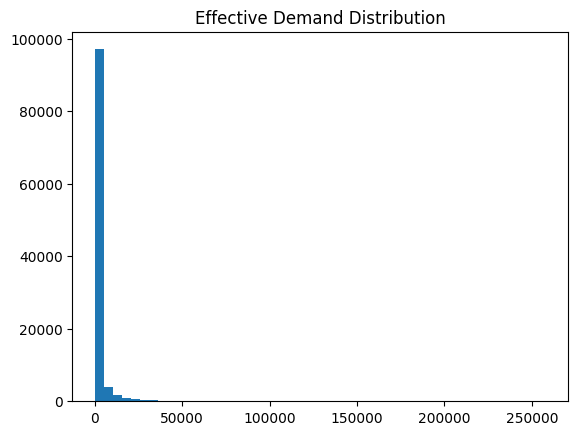

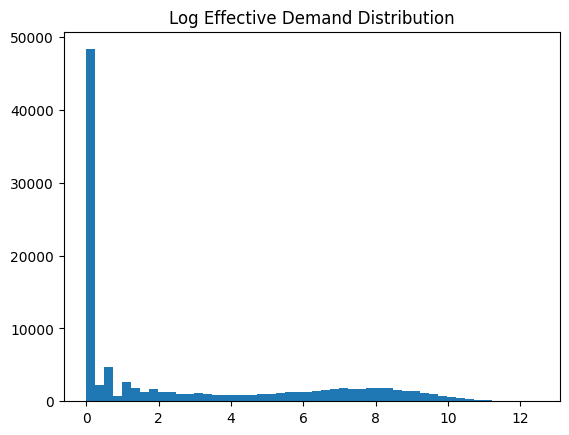

Skewness: 10.860146085018659
Kurtosis: 177.6002826199663
Zero Demand Ratio: 0.4557911138391803
Target Zero Ratio: 0.4605977619339912


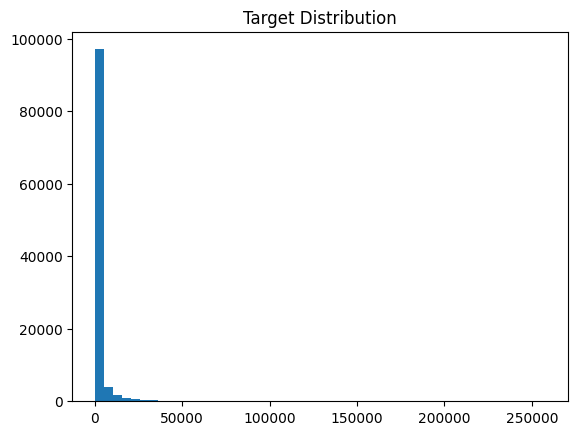

Target Skewness: 10.719814935043244
99th percentile: 33611.19999999984
Max Demand: 257986.0
                mean           std            max           min        count
count    2739.000000   2727.000000    2739.000000   2739.000000  2739.000000
mean     1615.253167    692.322606    3537.896728    456.634909    38.661920
std      6837.793440   2707.116788   13400.983483   2537.234382    11.882289
min         0.000000      0.000000       0.000000      0.000000     1.000000
25%         0.069767      0.237948       1.000000      0.000000    38.000000
50%         2.189130      3.021819      13.000000      0.000000    45.000000
75%       333.125181    232.045323    1092.500000      0.000000    46.000000
max    153324.582609  62957.345259  257986.000000  55150.000000    46.000000


In [24]:
### Data Distribution
Data_eda = rebuild_time_features(Base_Data.copy())
Data_eda = recompute_target(Data_eda)

required_cols = [
    "Target", "Lag1", "Lag2", "Lag3", "Lag6", "Lag12",
    "Rolling3M_Mean", "Rolling6M_Mean", "Rolling3M_Std"
]

Data_eda = Data_eda.dropna(subset=required_cols).copy()
Data_eda = Data_eda[Data_eda["Target"] >= 0].copy()

print(Data_eda.count())

plt.figure()
plt.hist(Data_eda["Clean_Demand"], bins=50)
plt.title("Effective Demand Distribution")
plt.show()

plt.figure()
plt.hist(np.log1p(Data_eda["Clean_Demand"]), bins=50)
plt.title("Log Effective Demand Distribution")
plt.show()

print("Skewness:", Data_eda["Clean_Demand"].skew())
print("Kurtosis:", Data_eda["Clean_Demand"].kurt())

zero_ratio = (Data_eda["Clean_Demand"] == 0).mean()
print("Zero Demand Ratio:", zero_ratio)

zero_ratio_target = (Data_eda["Target"] == 0).mean()
print("Target Zero Ratio:", zero_ratio_target)

plt.figure()
plt.hist(Data_eda["Target"], bins=50)
plt.title("Target Distribution")
plt.show()

print("Target Skewness:", Data_eda["Target"].skew())

q99 = Data_eda["Clean_Demand"].quantile(0.99)
print("99th percentile:", q99)
print("Max Demand:", Data_eda["Clean_Demand"].max())

sku_status = Data_eda.groupby("ItemCode")["Clean_Demand"].agg(["mean", "std", "max", "min", "count"])
print(sku_status.describe())

### SINGLE MODEL PIPELINE 

In [25]:
SINGLE_FEATURE_COLS = [
    "ItemCode", "ABC_Class",

    "Lag1", "Lag2", "Lag3", "Lag6", "Lag12",
    "Rolling3M_Mean", "Rolling6M_Mean", "Rolling3M_Std",

    "Month_Sin", "Month_Cos",

    "Bonus_Flag",
    "Free_Qty",
    "Free_Ratio",
    "Bonus_Flag_Lag1",
    "Free_Qty_Lag1",
    "Free_Ratio_Lag1",
    "Bonus_Frequency_12M",
    "Expected_Bonus_Month",
    "Expected_Bonus_NextMonth",
    "Post_Bonus_NextMonth_Flag",

    "Supply_Constraint_Flag",
    "Supply_Constraint_Lag1",
    "Supply_Constraint_Lag2",

    "Available_Primary_Inventory_Qty",
    "Distributor_Inventory_Qty",
    "Net_Available_Stock",
    "Stock_Cover_Months",
    "Demand_to_Stock_Ratio",
    "Primary_Stock_Cover",
    "Distributor_Stock_Cover",
    "Distributor_Stock_Cover_Lag1",

    "Inventory_Pressure",
    "Supply_Shock",
    "Recurring_Bonus_SKU",
    "Recurring_Bonus_Month",
    "Bonus_Cycle_Length",
    "Months_Since_Last_Bonus",
    "Avg_Bonus_Uplift",

    "Promo_Uplift_Lag1",
    "Promo_Uplift_Lag2",
    "Promo_Uplift_6M",
    "Last_Bonus_Demand",
    "Bonus_Sin",
    "Bonus_Cos",

    "ZeroRate_6M",
    "SKU_Mean_Demand",
    "SKU_ZeroRate",
    "SKU_CV"
]

#### Tune

In [26]:
TUNE_YEARS = [2023, 2024]

def single_objective(trial):

    params = {
    "objective": "reg:tweedie",
    "eval_metric": "rmse",
    "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.2, 1.55),

    "n_estimators": trial.suggest_int("n_estimators", 700, 1400),
    "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.06),
    "max_depth": trial.suggest_int("max_depth", 4, 7),

    "max_leaves": 64,
    "grow_policy": "lossguide",
    "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),

    "subsample": trial.suggest_float("subsample", 0.75, 0.9),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.75, 0.9),

    "gamma": trial.suggest_float("gamma", 0, 0.3),
    "reg_lambda": trial.suggest_float("reg_lambda", 2, 12),
    "reg_alpha": trial.suggest_float("reg_alpha", 0, 3),

    "random_state": 42,
    "tree_method": "hist",
    "n_jobs": -1
    }

    scores = []

    for year in TUNE_YEARS:

        train = Data[Data["Year"] < year].copy()
        valid = Data[Data["Year"] == year].copy()

        train, valid, bonus_map = apply_recurring_bonus_features(train, valid)
        train, valid, _ = apply_fold_adjustments(train, valid)

        combined = pd.concat([train, valid]).sort_values(["ItemCode","Year","Month_Number"])
        combined = rebuild_time_features(combined)

        train = combined[combined["Year"] < year].copy()
        valid = combined[combined["Year"] == year].copy()

        caps = compute_clip_caps(train, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
        train = apply_clip_caps(train, caps)
        valid  = apply_clip_caps(valid, caps)

        train = recompute_target(train)
        valid = recompute_target(valid)

        train = train.dropna(subset=[TARGET_COL])
        valid = valid.dropna(subset=[TARGET_COL])

        train, valid, _ = encode_itemcode(train, valid)

        model = xgb.XGBRegressor(**params)

        w_train = recency_weights(train, yearly_boost=0.25).astype(float)
        w_train *= np.where(train["ABC_Class"] == 0, 2.5,
                   np.where(train["ABC_Class"] == 1, 1.2, 1.0))

        Xtr = sanitize(train[SINGLE_FEATURE_COLS])
        ytr = train[TARGET_COL]
        Xva = sanitize(valid[SINGLE_FEATURE_COLS])
        yva = valid[TARGET_COL]
        print("NaN in train X:", Xtr.isna().sum().sum())

        model.fit(
            Xtr,
            ytr,
            sample_weight=w_train,
            eval_set=[(Xva, yva)],
            verbose=False
        )

        preds = model.predict(sanitize(valid[SINGLE_FEATURE_COLS]))
        scores.append(wmape(valid[TARGET_COL].values, preds))

    return np.mean(scores)

In [27]:
single_study = optuna.create_study(direction="minimize")
single_study.optimize(single_objective, n_trials=40)
single_best_params = single_study.best_params
print("\nSingle Model Best Params:", single_best_params)

[I 2026-03-15 20:30:14,117] A new study created in memory with name: no-name-55437de2-57ce-48d4-98d2-43ca9981e373


NaN in train X: 0
NaN in train X: 0


[I 2026-03-15 20:30:40,866] Trial 0 finished with value: 27.425059789846323 and parameters: {'tweedie_variance_power': 1.4242541422469688, 'n_estimators': 925, 'learning_rate': 0.03341091795988731, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.898713779255908, 'colsample_bytree': 0.8797979091982151, 'gamma': 0.12954003926616037, 'reg_lambda': 5.100343993315135, 'reg_alpha': 0.7911919318863783}. Best is trial 0 with value: 27.425059789846323.


NaN in train X: 0
NaN in train X: 0


[I 2026-03-15 20:31:19,576] Trial 1 finished with value: 27.790104633465198 and parameters: {'tweedie_variance_power': 1.5299228207627318, 'n_estimators': 915, 'learning_rate': 0.05121003074450217, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.7515753090029679, 'colsample_bytree': 0.8731092079530951, 'gamma': 0.1958145361144259, 'reg_lambda': 4.600214522589726, 'reg_alpha': 1.1379469922420538}. Best is trial 0 with value: 27.425059789846323.


...

NaN in train X: 0
NaN in train X: 0


[I 2026-03-15 20:49:47,929] Trial 38 finished with value: 27.32682852752622 and parameters: {'tweedie_variance_power': 1.4596621149806048, 'n_estimators': 757, 'learning_rate': 0.044055793847920535, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.8384906126715926, 'colsample_bytree': 0.817441743564168, 'gamma': 0.21601200830581926, 'reg_lambda': 7.385590339808572, 'reg_alpha': 0.592649658628309}. Best is trial 36 with value: 27.159253532521355.


NaN in train X: 0
NaN in train X: 0


[I 2026-03-15 20:50:14,999] Trial 39 finished with value: 27.639903954389943 and parameters: {'tweedie_variance_power': 1.5280422699306602, 'n_estimators': 815, 'learning_rate': 0.05286085908332852, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.8163936089670523, 'colsample_bytree': 0.8438341771386539, 'gamma': 0.20166269422846558, 'reg_lambda': 8.695358012294173, 'reg_alpha': 1.1217824147161861}. Best is trial 36 with value: 27.159253532521355.



Single Model Best Params: {'tweedie_variance_power': 1.4678848226371835, 'n_estimators': 780, 'learning_rate': 0.04859630280855227, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.8250000506547223, 'colsample_bytree': 0.7905201718686432, 'gamma': 0.17772160786794813, 'reg_lambda': 8.354420051761508, 'reg_alpha': 1.028682221341187}


#### Feature Pruning

In [28]:
single_best_feats, _, _, single_best_metrics, single_prune_log = iterative_feature_prune(
    Data=Data,
    start_features=SINGLE_FEATURE_COLS,
    target_col=TARGET_COL,
    best_params=single_best_params,
    drop_k=1,
    min_features=18,
    max_rounds=12,
    tolerance=0.10,
    n_repeats=5
)

print("✅ Single Best Metrics:", single_best_metrics)
print("✅ Single Best Features:", single_best_feats)
print(single_prune_log)

✅ Baseline | n_features=50 | WMAPE=28.2045 | MAE=430.1643 | RMSE=2383.1175 | Bias=-5.0455
Round 1 | Drop ['Bonus_Sin'] -> n=49 | WMAPE=28.5917 (best=28.2045)
❌ Rejected (worse than tolerance). Stopping.
✅ Single Best Metrics: {'WMAPE': 28.204467071745654, 'Bias': -5.045479258964501, 'MAE': 430.16432216794146, 'RMSE': 2383.117528439076, 'Underforecast_Rate': 16.624973165355076}
✅ Single Best Features: ['ItemCode', 'ABC_Class', 'Lag1', 'Lag2', 'Lag3', 'Lag6', 'Lag12', 'Rolling3M_Mean', 'Rolling6M_Mean', 'Rolling3M_Std', 'Month_Sin', 'Month_Cos', 'Bonus_Flag', 'Free_Qty', 'Free_Ratio', 'Bonus_Flag_Lag1', 'Free_Qty_Lag1', 'Free_Ratio_Lag1', 'Bonus_Frequency_12M', 'Expected_Bonus_Month', 'Expected_Bonus_NextMonth', 'Post_Bonus_NextMonth_Flag', 'Supply_Constraint_Flag', 'Supply_Constraint_Lag1', 'Supply_Constraint_Lag2', 'Available_Primary_Inventory_Qty', 'Distributor_Inventory_Qty', 'Net_Available_Stock', 'Stock_Cover_Months', 'Demand_to_Stock_Ratio', 'Primary_Stock_Cover', 'Distributor_Sto

#### Evaluation Model

In [29]:
# Final Single-Model Func
def train_single_evaluation_2025(Data, feature_cols, TARGET_COL, best_params):

    print("\n========== EVALUATION MODEL → TEST ON 2025 ==========")

    train_final = Data[Data["Year"] < 2025].copy()
    test_2025 = Data[Data["Year"] == 2025].copy()

    if train_final.empty or test_2025.empty:
        print("Need both train (<2025) and test (2025) data.")
        return None

    # Apply adjustments using train-only statistics
    train_final, test_2025, _ = apply_recurring_bonus_features(train_final, test_2025)
    train_final, test_2025, abc_map = apply_fold_adjustments(train_final, test_2025)

    combined = pd.concat([train_final, test_2025], ignore_index=True)
    combined = combined.sort_values(["ItemCode", "Year", "Month_Number"])
    combined = rebuild_time_features(combined)

    train_final = combined[combined["Year"] < 2025].copy()
    test_2025 = combined[combined["Year"] == 2025].copy()

    caps = compute_clip_caps(train_final, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    train_final = apply_clip_caps(train_final, caps)
    test_2025   = apply_clip_caps(test_2025, caps)

    # Recompute Target safely
    train_final = recompute_target(train_final).dropna(subset=[TARGET_COL]).copy()
    test_2025   = recompute_target(test_2025).dropna(subset=[TARGET_COL]).copy()

    train_final["ItemCode_Original"] = train_final["ItemCode"]
    test_2025["ItemCode_Original"] = test_2025["ItemCode"]

    train_final, test_2025, itemcode_categories = encode_itemcode(train_final, test_2025)

    # Train final model
    final_model = xgb.XGBRegressor(
        objective="reg:tweedie",
        eval_metric="rmse",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **best_params
    )

    w_final = recency_weights(train_final, yearly_boost=0.25).astype(float)
    w_final *= np.where(train_final["ABC_Class"] == 0, 2.5,
               np.where(train_final["ABC_Class"] == 1, 1.2, 1.0))

    Xtr = sanitize(train_final[feature_cols])
    ytr = train_final[TARGET_COL]
    print("NaN in train X:", Xtr.isna().sum().sum())

    final_model.fit(
        Xtr, 
        ytr,
        sample_weight=w_final,
        verbose=False
        )
   
    # Predict 2025
    test_2025["Pred"] = final_model.predict(sanitize(test_2025[feature_cols]))

    # WMAPE by ABC
    print("\n2025 WMAPE by ABC:")
    print(test_2025.groupby("ABC_Class", group_keys=False).apply(lambda x: wmape(x[TARGET_COL].values, x["Pred"].values)))
    
    overall_wmape = wmape(test_2025[TARGET_COL].values, test_2025["Pred"].values)
    print(f"\n2025 Overall WMAPE: {overall_wmape:.4f}")

    metrics = evaluate_all_metrics(
        test_2025[TARGET_COL].values,
        test_2025["Pred"].values)
    
    artifacts = {
        "model": final_model,
        "feature_cols": feature_cols,
        "best_params": best_params,
        "itemcode_categories": itemcode_categories,
        "abc_map": abc_map,
        "clip_caps": caps
    }

    return artifacts, test_2025, metrics

#### Deployement Model

In [30]:
def train_single_deployment_model(Data, feature_cols, TARGET_COL, best_params):

    print("\n========== DEPLOYMENT MODEL → TRAIN ON ALL COMPLETE DATA ==========")

    deploy_df = Data.copy().sort_values(["ItemCode", "Year", "Month_Number"])

    # Build recurring bonus features using all complete data
    bonus_pattern_df = detect_recurring_bonus_skus(deploy_df)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    deploy_df = deploy_df.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    deploy_df = deploy_df.merge(bonus_pattern_df, on="ItemCode", how="left")

    deploy_df, _ = apply_sku_cap(deploy_df.copy(), deploy_df.copy())

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        deploy_df[c] = deploy_df[c].fillna(0)

    deploy_df["Avg_Bonus_Uplift"] = deploy_df["Avg_Bonus_Uplift"].fillna(1.0)

    # ABC based on all complete data
    sku_total = (deploy_df.groupby("ItemCode")["Clean_Demand"].sum().sort_values(ascending=False))
    cum_pct = sku_total.cumsum() / sku_total.sum()

    abc_series = pd.cut(
        cum_pct,
        bins=[0, 0.7, 0.9, 1.0],
        labels=[0, 1, 2]
    )
    abc_map = abc_series.to_dict()
    deploy_df["ABC_Class"] = deploy_df["ItemCode"].map(abc_map).fillna(2)

    deploy_df = add_bonus_cycle_features(deploy_df)
    deploy_df = rebuild_time_features(deploy_df)

    caps = compute_clip_caps(deploy_df, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    deploy_df = apply_clip_caps(deploy_df, caps)

    deploy_df = recompute_target(deploy_df).dropna(subset=[TARGET_COL]).copy()

    deploy_df["ItemCode_Original"] = deploy_df["ItemCode"]

    deploy_df, _, itemcode_categories = encode_itemcode(deploy_df, deploy_df)

    deploy_model = xgb.XGBRegressor(
        objective="reg:tweedie",
        eval_metric="rmse",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **best_params
    )

    w_deploy = recency_weights(deploy_df, yearly_boost=0.25).astype(float)
    w_deploy *= np.where(deploy_df["ABC_Class"] == 0, 2.5,
                np.where(deploy_df["ABC_Class"] == 1, 1.2, 1.0))

    Xtr = sanitize(deploy_df[feature_cols])
    ytr = deploy_df[TARGET_COL]

    deploy_model.fit(
        Xtr,
        ytr,
        sample_weight=w_deploy,
        verbose=False
    )

    artifacts = {
        "model": deploy_model,
        "feature_cols": feature_cols,
        "best_params": best_params,
        "itemcode_categories": itemcode_categories,
        "abc_map": abc_map,
        "clip_caps": caps
    }

    return artifacts, deploy_df

#### Model Save

In [31]:
# =========================
# FINAL EVALUATION MODEL
# =========================
single_eval_artifacts, single_test_2025, single_eval_metrics = train_single_evaluation_2025(
    Data=Data,
    feature_cols=single_best_feats,
    TARGET_COL=TARGET_COL,
    best_params=single_best_params
)

print("\n===== SINGLE EVALUATION METRICS =====")
print(single_eval_metrics)

# Save evaluation artifacts separately if needed
joblib.dump(single_eval_artifacts, "single_model_eval_artifacts.pkl")


# =========================
# FINAL DEPLOYMENT MODEL
# =========================
single_deploy_artifacts, single_deploy_train_df = train_single_deployment_model(
    Data=Data,
    feature_cols=single_best_feats,
    TARGET_COL=TARGET_COL,
    best_params=single_best_params
)

# Save deployment artifacts for inference
joblib.dump(single_deploy_artifacts, "single_model_deploy_artifacts.pkl")


========== EVALUATION MODEL → TEST ON 2025 ==========
NaN in train X: 0

2025 WMAPE by ABC:
ABC_Class
0.0    24.907602
1.0    29.504870
2.0    38.596825
dtype: float64

2025 Overall WMAPE: 28.2045

===== SINGLE EVALUATION METRICS =====
{'WMAPE': 28.204467071745654, 'Bias': -5.045479258964501, 'MAE': 430.16432216794146, 'RMSE': 2383.117528439076, 'Underforecast_Rate': 16.624973165355076}

========== DEPLOYMENT MODEL → TRAIN ON ALL COMPLETE DATA ==========


/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_9476/661579939.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_2025.groupby("ABC_Class", group_keys=False).apply(lambda x: wmape(x[TARGET_COL].values, x["Pred"].values)))


['single_model_deploy_artifacts.pkl']

# Visualize

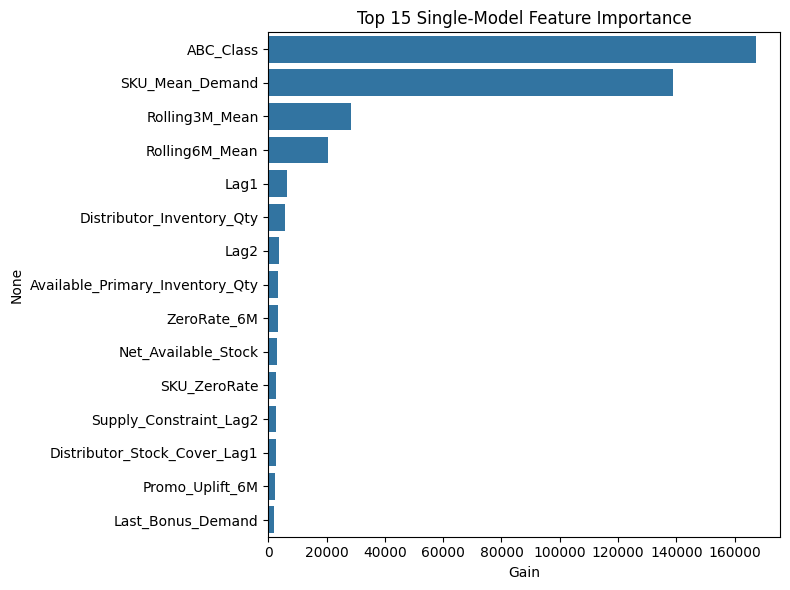

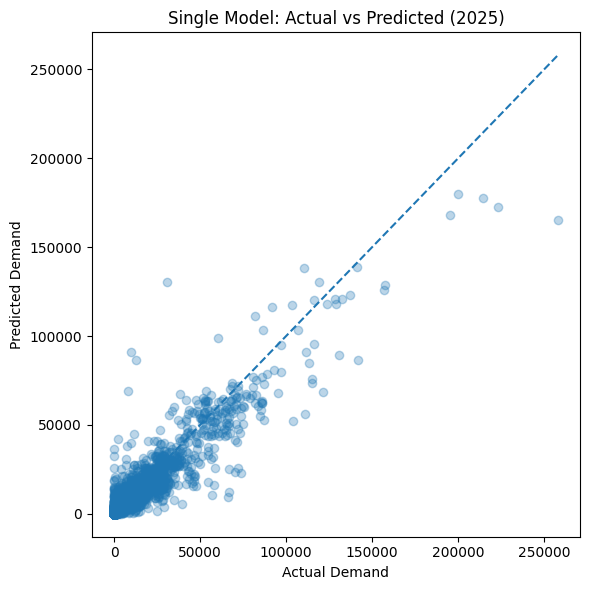

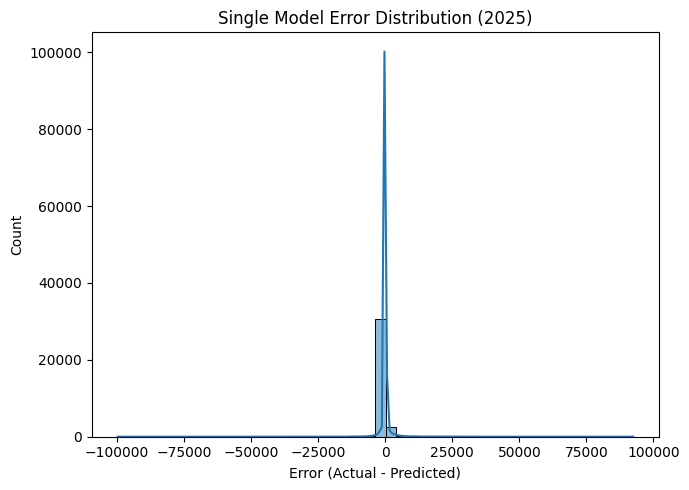

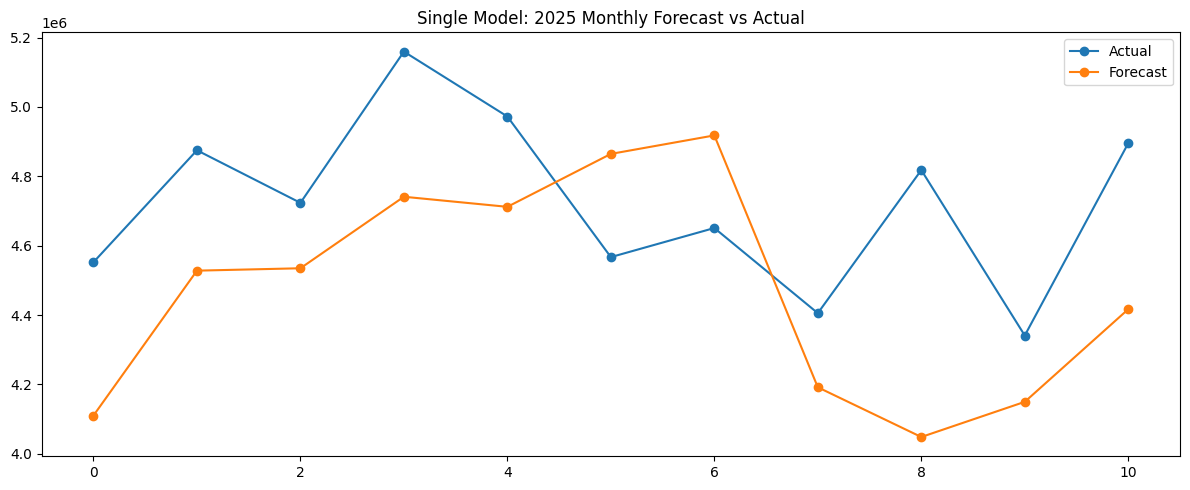

/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_8306/634434111.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df.groupby("ABC_Class")


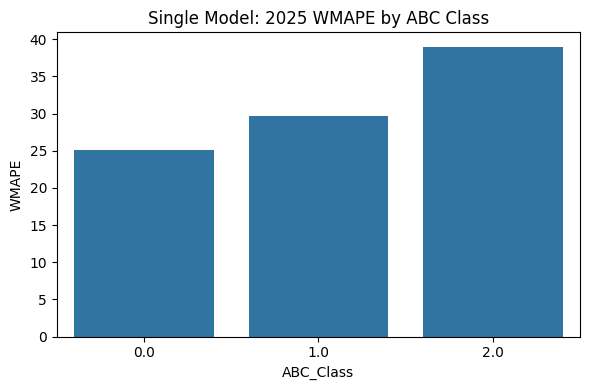

/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_8306/634434111.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df.groupby(col)


   ABC_Class      WMAPE
0        0.0  25.168602
1        1.0  29.654095
2        2.0  38.986488


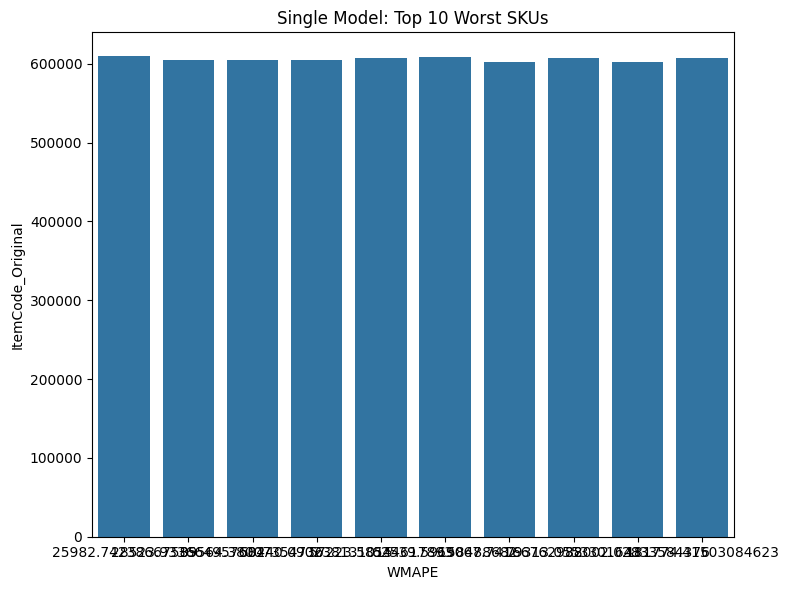

,ItemCode_Original,WMAPE
1560,607888,181774.415031
328,602763,82002.028336
1413,607309,79313.055330
327,602753,69067.741668
1615,608059,62539.591585
1281,607038,57223.585446
577,604807,50240.090238
502,604298,35564.380074
588,604871,28523.933665
2364,609456,25982.742387


In [171]:
# =========================
# SINGLE MODEL VISUALIZATION - EVAL
# =========================

def plot_single_feature_importance(model, top_n=15):
    importance = model.get_booster().get_score(importance_type="gain")
    importance_df = (
        pd.DataFrame.from_dict(importance, orient="index", columns=["Gain"])
        .sort_values("Gain", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(x="Gain", y=importance_df.index, data=importance_df)
    plt.title(f"Top {top_n} Single-Model Feature Importance")
    plt.tight_layout()
    plt.show()


def plot_single_actual_vs_pred(test_df):
    y_test = test_df["Target"].values
    preds = test_df["Pred"].values

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.3)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual Demand")
    plt.ylabel("Predicted Demand")
    plt.title("Single Model: Actual vs Predicted (2025)")
    plt.tight_layout()
    plt.show()


def plot_single_error_distribution(test_df):
    errors = test_df["Target"] - test_df["Pred"]

    plt.figure(figsize=(7, 5))
    sns.histplot(errors, bins=50, kde=True)
    plt.title("Single Model Error Distribution (2025)")
    plt.xlabel("Error (Actual - Predicted)")
    plt.tight_layout()
    plt.show()


def plot_single_time_series_monthly(test_df):
    monthly = (
        test_df.groupby(["Year", "Month_Number"])
        .agg({"Target": "sum", "Pred": "sum"})
        .reset_index()
        .sort_values(["Year", "Month_Number"])
    )

    plt.figure(figsize=(12, 5))
    plt.plot(monthly["Target"].values, label="Actual", marker="o")
    plt.plot(monthly["Pred"].values, label="Forecast", marker="o")
    plt.legend()
    plt.title("Single Model: 2025 Monthly Forecast vs Actual")
    plt.tight_layout()
    plt.show()


def plot_single_abc_performance(test_df):
    abc_scores = (
        test_df.groupby("ABC_Class")
        .apply(lambda x: wmape(x["Target"].values, x["Pred"].values))
        .reset_index(name="WMAPE")
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=abc_scores, x="ABC_Class", y="WMAPE")
    plt.title("Single Model: 2025 WMAPE by ABC Class")
    plt.tight_layout()
    plt.show()

    print(abc_scores)


def plot_single_top_error_skus(test_df, top_n=10):
    col = "ItemCode_Original" if "ItemCode_Original" in test_df.columns else "ItemCode"

    sku_error = (
        test_df.groupby(col)
        .apply(lambda x: wmape(x["Target"].values, x["Pred"].values))
        .reset_index(name="WMAPE")
        .sort_values("WMAPE", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(data=sku_error, x="WMAPE", y=col)
    plt.title(f"Single Model: Top {top_n} Worst SKUs")
    plt.tight_layout()
    plt.show()

    return sku_error


plot_single_feature_importance(single_eval_artifacts["model"])
plot_single_actual_vs_pred(single_test_2025)
plot_single_error_distribution(single_test_2025)
plot_single_time_series_monthly(single_test_2025)
plot_single_abc_performance(single_test_2025)
plot_single_top_error_skus(single_test_2025, top_n=10)

# Inference

In [32]:
# =========================
# SINGLE MODEL INFERENCE - HISTORY + FORWARD
# =========================

def single_model_history_and_forecast(sku_code, next_month_bonus, artifacts, raw_data, history_months=12):
    model = artifacts["model"]
    feature_cols = artifacts["feature_cols"]
    itemcode_categories = artifacts["itemcode_categories"]
    abc_map = artifacts["abc_map"]
    caps = artifacts["clip_caps"]

    sku_code = str(sku_code)

    df = raw_data.copy().sort_values(["ItemCode", "Year", "Month_Number"]).reset_index(drop=True)
    df["ItemCode_Original"] = df["ItemCode"].astype(str)

    sku_hist_raw = df[df["ItemCode_Original"] == sku_code].copy()
    if sku_hist_raw.empty:
        print("SKU not found.")
        return None

    # -------------------------------------------------
    # Rebuild full deploy-style feature frame
    # -------------------------------------------------
    bonus_pattern_df = detect_recurring_bonus_skus(df)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    df = df.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    df = df.merge(bonus_pattern_df, on="ItemCode", how="left")

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        df[c] = df[c].fillna(0)

    df["Avg_Bonus_Uplift"] = df["Avg_Bonus_Uplift"].fillna(1.0)

    df["ABC_Class"] = df["ItemCode"].map(abc_map).fillna(2)

    df = add_bonus_cycle_features(df)
    df = rebuild_time_features(df)
    df = apply_clip_caps(df, caps)

    # -------------------------------------------------
    # Encode ItemCode same way as training
    # -------------------------------------------------
    cat_to_code = {str(k): i for i, k in enumerate(itemcode_categories)}
    unk_code = len(cat_to_code)

    df["ItemCode_Encoded"] = df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    # model expects encoded ItemCode in column named ItemCode
    df_model = df.copy()
    df_model["ItemCode"] = df_model["ItemCode_Encoded"]

    # -------------------------------------------------
    # Historical predicted values
    # -------------------------------------------------
    sku_hist = df_model[df_model["ItemCode_Original"] == sku_code].copy()
    sku_hist = sku_hist.sort_values(["Year", "Month_Number"]).reset_index(drop=True)

    hist_pred = model.predict(sanitize(sku_hist[feature_cols]))
    sku_hist["Predicted"] = hist_pred

    actual_col = "Clean_Demand" if "Clean_Demand" in sku_hist.columns else "Observed_Demand"
    sku_hist["Actual"] = sku_hist[actual_col]
    sku_hist["Error"] = sku_hist["Actual"] - sku_hist["Predicted"]
    sku_hist["Abs_Error"] = np.abs(sku_hist["Error"])

    history_view = sku_hist[[
        "ItemCode_Original",
        "Year",
        "Month_Number",
        "Bonus_Flag",
        "Actual",
        "Predicted",
        "Error",
        "Abs_Error"
    ]].tail(history_months).copy()

    # -------------------------------------------------
    # Forward next-month row
    # -------------------------------------------------
    last_row = df[df["ItemCode_Original"] == sku_code].sort_values(["Year", "Month_Number"]).iloc[-1:].copy()

    next_month = int(last_row["Month_Number"].iloc[0] + 1)
    next_year = int(last_row["Year"].iloc[0])

    if next_month > 12:
        next_month = 1
        next_year += 1

    new_row = last_row.copy()
    new_row["Year"] = next_year
    new_row["Month_Number"] = next_month
    new_row["Bonus_Flag"] = int(next_month_bonus)

    # append forward row to original raw-style df
    df_forward = df.drop(columns=["ItemCode_Encoded"], errors="ignore").copy()
    df_forward = pd.concat([df_forward, new_row], ignore_index=True)

    # rebuild features again including forward row
    bonus_pattern_df_f = detect_recurring_bonus_skus(df_forward)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    df_forward = df_forward.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    df_forward = df_forward.merge(bonus_pattern_df_f, on="ItemCode", how="left")

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        df_forward[c] = df_forward[c].fillna(0)

    df_forward["Avg_Bonus_Uplift"] = df_forward["Avg_Bonus_Uplift"].fillna(1.0)
    df_forward["ABC_Class"] = df_forward["ItemCode"].map(abc_map).fillna(2)

    df_forward = add_bonus_cycle_features(df_forward)
    df_forward = rebuild_time_features(df_forward)
    df_forward = apply_clip_caps(df_forward, caps)

    df_forward["ItemCode_Original"] = df_forward["ItemCode"].astype(str)
    df_forward["ItemCode_Encoded"] = df_forward["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    df_forward_model = df_forward.copy()
    df_forward_model["ItemCode"] = df_forward_model["ItemCode_Encoded"]

    next_row = df_forward_model[
        (df_forward_model["ItemCode_Original"] == sku_code) &
        (df_forward_model["Year"] == next_year) &
        (df_forward_model["Month_Number"] == next_month)
    ].copy()

    forecast = float(model.predict(sanitize(next_row[feature_cols]))[0])

    forecast_row = {
        "ItemCode_Original": sku_code,
        "Year": next_year,
        "Month_Number": next_month,
        "Bonus_Flag": int(next_month_bonus),
        "Actual": np.nan,
        "Predicted": forecast,
        "Error": np.nan,
        "Abs_Error": np.nan
    }

    return {
        "SKU": sku_code,
        "Forecast_Year": next_year,
        "Forecast_Month": next_month,
        "NextMonthBonus": int(next_month_bonus),
        "NextMonthForecast": forecast,
        "History": history_view,
        "Forecast_Row": forecast_row
    }

In [ ]:
result = single_model_history_and_forecast(
    sku_code="604664",
    next_month_bonus=0,
    artifacts=single_deploy_artifacts,
    raw_data=Base_Data.copy(),
    history_months=12
)

results_xgb = []


In [38]:
import re

raw_skus = """
601182
612675
607071
601180
602561
608155
600604
601174
602386
604664
600660
607276
612119
612176
600462
612373
601330
606997
605622
612117
606168
600461
600319
600932
612677
606365
606636
600931
605613
606995
608134
600695
605375
603717
607440
607314
607087
602388
610899
607628
600631
600667
612055
606164
600618
600613
607113
603706
604109
612051
607626
612134
601973
600615
600701
600694
612052
612496
607657
600726
604470
612054
606194
600617
606785
603205
607854
604149
601337
603944
605182
605160
600460
600616
612057
602948
608526
608131
607111
605173
604177
607008
601350
604610
600702
610023
600457
600621
603775
600724
604585
612324
604925
607002
606994
607273
600720
608177
603206
607316
605355
605174
612493
606395
607049
602562
603196
606155
612056
605937
611050
601176
607000
607076
603323
604023
600700
603990
607060
600311
603991
603221
612058
607969
607030
607056
600308
606402
600602
600612
602324
607043
600921
602387
607146
607053
602854
612069
600586
606301
605374
601339
605156
602435
600706
604774
607095
606428
612049
607878
612062
600929
608548
610869
605565
607639
606413
601178
601351
604100
607057
612402
607034
607305
612048
612521
604004
607016
612136
605157
605508
612067
608118
603168
606558
607723
608224
612085
611703
611585
607870
606153
606415
610025
600707
603581
606397
602434
607017
612083
608180
606646
607855
607055
612061
606307
602468
600830
612374
606927
607094
611584
607949
606657
600614
605189
602512
607308
608135
608136
611355
605181
607195
612537
607277
612050
611565
601937
603378
607656
608923
607028
606430
604924
600547
612535
601177
612497
612389
607627
606950
605227
606427
600837
606999
607089
606757
603106
604986
604146
612068
611202
607952
603966
610924
605358
612107
608176
607033
608128
607960
606810
603023
603612
607014
600716
604810
608119
608147
607101
604315
607724
612091
607072
612676
606653
606431
607961
603493
607667
612060
612378
607069
606669
604003
612109
600620
607265
608924
607968
604401
605584
612541
607027
604099
600831
604666
607877
603322
605162
611705
603109
601352
612047
600661
612390
601133
601140
610677
601938
606650
607962
604152
611622
607097
612517
603703
608094
608210
600458
612093
606118
607933
601338
603774
611628
607931
607793
612053
607068
607063
607317
608112
606166
604155
608132
600603
606841
607100
607620
605507
604464
610671
611239
606651
611128
608123
608127
602416
612382
605165
600919
604465
601134
611213
606583
607970
606637
601179
606414
606598
607070
612087
605556
612435
605206
612074
604066
612530
600542
612380
607630
608536
603126
606353
610870
602296
605133
604098
608122
608225
607966
606843
608056
611524
605703
604621
604979
612101
607024
601974
605543
605209
612089
605423
606273
608163
602949
602881
606177
606659
607584
606163
612063
606179
612381
612078
600823
608146
605183
612059
606180
612121
605141
612040
612073
611798
602661
606363
608130
603160
600622
606182
603203
606662
607246
608875
611799
605225
601506
611631
608412
603773
603582
603652
606844
604808
607091
606783
612037
607123
607147
612044
605224
605223
606683
604793
607304
609610
612407
611635
607102
607338
607695
605935
602417
610442
612113
607380
612322
611610
605936
607844
607950
602674
612177
611603
604156
606120
605190
607926
603324
612372
610063
605363
605927
610877
605544
606398
611626
608397
612111
606181
610026
604738
611588
602662
607608
610964
612027
603755
607079
600478
605158
610384
608172
607635
607619
603434
611609
600600
601195
607633
607015
607964
603169
607637
606169
605349
607126
607595
611625
611286
603644
601115
604468
605432
612513
610871
604067
600601
610965
610020
605542
606174
601246
612385
603108
611637
608211
603058
606572
601336
600315
604058
611613
611636
605163
607112
600698
610701
607345
600721
607236
611717
612408
607607
607612
611800
605144
607905
605356
611439
612557
610700
612095
612678
607864
605357
605583
603306
607336
601141
611616
610625
612025
600719
608137
611162
608531
607074
606713
600822
608949
612307
606624
602610
607953
605615
606573
607296
607636
607965
611632
602663
607382
600654
605207
611627
609043
611630
611741
611740
612140
602673
605195
612522
611797
607906
606638
607006
607813
612376
606991
604593
605485
612306
601348
607150
601868
608532
600587
604737
606758
611641
606374
606625
608530
612138
612406
610672
612026
603551
601237
612305
612455
611284
606122
606672
612501
611706
606838
601137
608950
611904
612502
611718
603620
610868
607011
607605
606910
606376
611590
612046
605545
604959
612041
601349
606075
610611
611404
605208
604624
602180
605535
611724
608150
611633
611607
610933
611591
611620
611725
606675
600589
611615
612034
612456
611716
610922
611976
612308
611582
612504
610932
604625
612064
612070
605510
607294
607846
611808
611617
609608
611259
611908
602882
604145
612577
611726
607090
611810
612066
605210
608535
602685
605973
611903
612379
611801
600955
605657
612410
611723
607285
611694
605795
610936
604942
611727
611909
612524
611612
611768
605289
601142
611443
611624
611913
600914
607119
611214
611739
601511
606840
612411
611708
600588
611780
602025
611811
600958
603692
607923
609042
611695
606654
611611
612042
606660
611784
611897
606043
612503
605511
611640
603321
603640
611742
611614
601154
611440
611761
611642
611966
605796
610029
611689
612431
605793
611907
606618
611728
611782
612386
611914
608227
611634
608162
611898
607875
611722
610586
611735
611967
611767
605794
604035
611762
611971
601175
606756
606790
611936
606063
611769
604623
605196
611444
606377
605534
611442
611910
611764
604096
606044
603305
611406
611734
612065
610584
611835
611937
600997
603981
611707
603643
602746
611970
604580
610028
611434
606676
611946
601131
605783
611912
611945
611819
610955
604915
611873
609345
610619
611729
611719
611765
611881
601156
611818
610935
611619
611606
612319
607924
611592
611809
611880
604170
611823
611824
600952
604347
611803
611871
607606
611888
611896
601869
608173
611760
612542
604736
612028
611915
612309
601160
603304
606619
611713
611738
611953
609044
611882
601143
601229
605736
611772
608534
611248
611812
612321
612744
612746
612115
608064
606622
611901
611804
605458
607237
608066
602413
605187
611445
611968
605268
611877
612035
612397
611770
611876
611911
611954
607031
611855
611938
607632
606998
611714
611965
612323
612405
612745
604573
611618
611747
611935
600459
604968
610226
611763
611832
611939
611972
605546
605798
611831
611981
607631
605301
611730
611947
605251
605799
610268
611721
611786
605304
605797
607219
611407
611711
611841
611899
604920
605241
611856
611900
612395
606293
610577
611820
611982
601112
606666
608391
611447
611837
611872
611778
611842
601168
605800
605809
611736
611805
611858
611952
607373
610578
610880
611608
611788
611932
611709
611802
611883
611916
601153
605168
607085
610579
610581
611906
611929
606750
611446
611806
611878
611743
611789
611844
611994
611997
612387
604574
605072
606623
611668
611744
611833
611955
612399
600828
604900
606617
607514
607515
608992
610574
611825
611857
611969
611973
612310
606438
611927
611931
612527
600310
605442
611861
611887
611715
611731
611793
611995
607371
609238
611792
611879
611933
611944
611980
601865
604809
611838
611840
611854
611885
611993
603523
600481
601235
603083
605286
606077
607058
607370
607911
608238
611779
611892
607516
601854
604916
605596
611712
611781
611790
611817
611822
611884
611983
612602
612603
611787
611875
612400
604910
605720
606747
608981
611751
611766
611934
612596
601170
602647
607959
609239
610583
611403
611843
611923
611948
611951
612604
601169
602575
605388
607303
607307
610575
610580
610702
611745
611750
611757
611849
611859
611874
611886
611905
611964
611985
611996
612606
602868
604923
606888
608978
608993
609215
609331
611508
611531
611664
611720
611746
611753
611777
611986
612597
604474
603526
604919
606709
606746
606887
606900
608979
608991
609339
611238
611733
611749
611754
611828
611830
611917
611925
611930
612607
600153
605238
605342
606068
606424
606886
608987
611783
611920
611941
611989
612388
612601
603524
600699
605245
605259
606957
607083
608883
609200
611568
611665
611710
611893
611918
611922
611990
612599
600909
601238
605789
606626
606962
607084
608339
608885
608994
609020
611340
611572
611785
611791
611860
611928
611942
611991
612440
612600
604475
604581
605248
605252
605265
605514
605912
606178
606983
606986
608034
608156
608308
608311
608514
608990
609197
609325
609344
610055
610605
611409
611511
611530
611574
611732
611748
611758
611845
611866
611868
611889
611891
611894
611919
611921
611924
611940
612033
612595
600469
604300
604902
605260
605306
605313
605325
605513
605698
605708
606070
606588
607045
607187
608306
608466
608884
608976
608989
608995
609037
609133
609199
609213
609231
609332
609355
609404
609405
609575
611334
611335
611337
611339
611509
611510
611569
611776
611834
611853
611902
611926
611943
611987
611992
612331
612594
612605
608115
608116
602578
603318
604301
604302
604303
605164
605239
605253
605302
605303
605305
605328
605332
605336
605344
605524
605526
605700
605714
606260
606354
606401
606616
606736
606890
606897
606961
606964
606987
607726
608313
608323
608454
608516
608881
608892
608977
609045
609056
609061
609168
609209
609237
609266
609284
609286
609312
609313
609326
609327
609334
609351
609365
611017
611408
611507
611512
611571
611573
611752
611807
611816
611821
611827
611829
611863
611949
611999
612325
612519
612608
612702
612734
604571
600444
600477
602581
603344
604298
604899
604908
604914
605125
605271
605272
605275
605278
605290
605311
605312
605314
605316
605333
605338
605429
605436
605519
605522
605590
605591
605647
605650
605651
605712
605719
605918
605919
606071
606451
606587
606695
606696
606697
606889
606955
606956
606966
607217
607218
607257
607268
607301
607474
607727
608012
608021
608024
608031
608032
608091
608092
608213
608215
608315
608318
608338
608340
608588
608597
608880
608893
608974
608975
608980
608986
608996
609036
609062
609079
609166
609224
609232
609241
609249
609260
609263
609265
609268
609280
609285
609287
609288
609333
609335
609346
609364
609567
610053
610161
610233
610381
610419
610535
610573
610631
610639
610927
611091
611144
611341
611343
611411
611506
611575
611576
611756
611771
611775
611836
611862
611864
611865
611867
611869
611870
611890
611958
611960
611961
611984
611988
611998
612007
612313
612353
612354
612355
612356
612357
612358
612359
612360
612583
612686
612700
612701
612733
612736
612737
612738
612739
612740
612741
612742
612743
604473
"""

sku_list = [int(x) for x in re.findall(r"\d+", raw_skus)]
print("SKU count:", len(sku_list))
print(sku_list[:20])

SKU count: 1491
[601182, 612675, 607071, 601180, 602561, 608155, 600604, 601174, 602386, 604664, 600660, 607276, 612119, 612176, 600462, 612373, 601330, 606997, 605622, 612117]


In [ ]:
for sku in sku_list:

    try:

        res = single_model_history_and_forecast(
            sku_code=sku,
            next_month_bonus=0,   # or your real bonus flag
            artifacts=single_deploy_artifacts,
            raw_data=Base_Data.copy()
        )

        pred = res["NextMonthForecast"]

        results_xgb.append({
            "ItemCode": sku,
            "XGB_Prediction": pred
        })

    except:
        continue


xgb_predictions = pd.DataFrame(results_xgb)

SKU not found.


In [34]:
history_table = result["History"].copy()
forecast_table = pd.DataFrame([result["Forecast_Row"]])

final_table = pd.concat([history_table, forecast_table], ignore_index=True)
print(final_table)

   ItemCode_Original  Year  Month_Number  Bonus_Flag   Actual     Predicted  \
0             602561  2025             2           0  57215.0  57725.222656   
1             602561  2025             3           0  67089.0  58046.621094   
2             602561  2025             4           0  74818.0  64075.949219   
3             602561  2025             5           1  66734.0  58677.558594   
4             602561  2025             6           1  65630.0  65120.699219   
5             602561  2025             7           0  55644.0  63424.031250   
6             602561  2025             8           0  62882.0  55392.699219   
7             602561  2025             9           1  61960.0  57357.609375   
8             602561  2025            10           1  67253.0  56178.734375   
9             602561  2025            11           1  59236.0  54888.453125   
10            602561  2025            12           1  73092.0  61606.429688   
11            602561  2026             1           1

# LightGBM

In [141]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
import joblib
from sklearn.inspection import permutation_importance
import seaborn as sns

In [142]:
def encode_itemcode_lgbm(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    categories = pd.Index(train_df["ItemCode"].astype(str).unique())
    cat_to_code = {k: i for i, k in enumerate(categories)}
    unk_code = len(cat_to_code)

    train_df["ItemCode"] = train_df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)
    valid_df["ItemCode"] = valid_df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    # important for LightGBM categorical split handling
    train_df["ItemCode"] = train_df["ItemCode"].astype("category")
    valid_df["ItemCode"] = valid_df["ItemCode"].astype("category")

    if "ABC_Class" in train_df.columns:
        train_df["ABC_Class"] = train_df["ABC_Class"].astype("category")
        valid_df["ABC_Class"] = valid_df["ABC_Class"].astype("category")

    return train_df, valid_df, categories

In [143]:
TARGET_COL = "Target"

SINGLE_FEATURE_COLS = [
    "ItemCode", "ABC_Class",

    "Lag1", "Lag2", "Lag3", "Lag6", "Lag12",
    "Rolling3M_Mean", "Rolling6M_Mean", "Rolling3M_Std",

    "Month_Sin", "Month_Cos",

    "Bonus_Flag",
    "Free_Qty",
    "Free_Ratio",
    "Bonus_Flag_Lag1",
    "Free_Qty_Lag1",
    "Free_Ratio_Lag1",
    "Bonus_Frequency_12M",
    "Expected_Bonus_Month",
    "Expected_Bonus_NextMonth",
    "Post_Bonus_NextMonth_Flag",

    "Supply_Constraint_Flag",
    "Supply_Constraint_Lag1",
    "Supply_Constraint_Lag2",

    "Available_Primary_Inventory_Qty",
    "Distributor_Inventory_Qty",
    "Net_Available_Stock",
    "Stock_Cover_Months",
    "Demand_to_Stock_Ratio",
    "Primary_Stock_Cover",
    "Distributor_Stock_Cover",
    "Distributor_Stock_Cover_Lag1",

    "Inventory_Pressure",
    "Supply_Shock",
    "Recurring_Bonus_SKU",
    "Recurring_Bonus_Month",
    "Bonus_Cycle_Length",
    "Months_Since_Last_Bonus",
    "Avg_Bonus_Uplift",

    "Promo_Uplift_Lag1",
    "Promo_Uplift_Lag2",
    "Promo_Uplift_6M",
    "Last_Bonus_Demand",
    "Bonus_Sin",
    "Bonus_Cos",

    "ZeroRate_6M",
    "SKU_Mean_Demand",
    "SKU_ZeroRate",
    "SKU_CV"
]

CATEGORICAL_FEATURES = ["ItemCode", "ABC_Class"]

In [144]:
TUNE_YEARS = [2023, 2024]

def single_objective_lgb(trial):
    params = {
        "objective": "tweedie",
        "metric": "rmse",
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.15, 1.55),

        "n_estimators": trial.suggest_int("n_estimators", 700, 1800),
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.06),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 4, 10),

        "min_child_samples": trial.suggest_int("min_child_samples", 15, 80),
        "subsample": trial.suggest_float("subsample", 0.75, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.75, 0.95),

        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 12.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 4.0),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.3),

        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    scores = []

    for year in TUNE_YEARS:
        train = Data[Data["Year"] < year].copy()
        valid = Data[Data["Year"] == year].copy()

        train, valid, _ = apply_recurring_bonus_features(train, valid)
        train, valid, _ = apply_fold_adjustments(train, valid)

        combined = pd.concat([train, valid]).sort_values(["ItemCode", "Year", "Month_Number"])
        combined = rebuild_time_features(combined)

        train = combined[combined["Year"] < year].copy()
        valid = combined[combined["Year"] == year].copy()

        caps = compute_clip_caps(train, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
        train = apply_clip_caps(train, caps)
        valid = apply_clip_caps(valid, caps)

        train = recompute_target(train).dropna(subset=[TARGET_COL]).copy()
        valid = recompute_target(valid).dropna(subset=[TARGET_COL]).copy()

        train, valid, _ = encode_itemcode_lgbm(train, valid)

        Xtr = sanitize(train[SINGLE_FEATURE_COLS])
        ytr = train[TARGET_COL]
        Xva = sanitize(valid[SINGLE_FEATURE_COLS])
        yva = valid[TARGET_COL]

        w_train = recency_weights(train, yearly_boost=0.25).astype(float)
        w_train *= np.where(train["ABC_Class"].astype(int) == 0, 2.5,
                   np.where(train["ABC_Class"].astype(int) == 1, 1.2, 1.0))

        model = lgb.LGBMRegressor(**params)

        model.fit(
            Xtr,
            ytr,
            sample_weight=w_train,
            eval_set=[(Xva, yva)],
            eval_metric="l1",
            categorical_feature=CATEGORICAL_FEATURES,
            callbacks=[
                lgb.early_stopping(100),
                lgb.log_evaluation(0)
            ]
        )

        preds = model.predict(Xva, num_iteration=model.best_iteration_)
        preds = np.clip(preds, 0, None)

        scores.append(wmape(yva.values, preds))

    return np.mean(scores)

In [145]:
single_study_lgb = optuna.create_study(direction="minimize")
single_study_lgb.optimize(single_objective_lgb, n_trials=40)

single_best_params_lgb = single_study_lgb.best_params
print("\nLightGBM Best Params:", single_best_params_lgb)

[I 2026-03-15 19:03:10,312] A new study created in memory with name: no-name-bcfc0889-1db1-4f1d-a4d1-4d19eb6c5938


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[226]	valid_0's l1: 559.558	valid_0's rmse: 2929.3
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[724]	valid_0's l1: 464.607	valid_0's rmse: 2403.22


[I 2026-03-15 19:03:50,237] Trial 0 finished with value: 29.940213353366122 and parameters: {'tweedie_variance_power': 1.3915153644710376, 'n_estimators': 1759, 'learning_rate': 0.01899413084736826, 'num_leaves': 120, 'max_depth': 9, 'min_child_samples': 59, 'subsample': 0.9472631345093936, 'colsample_bytree': 0.912272431113196, 'reg_lambda': 7.854447296792452, 'reg_alpha': 0.715801931701654, 'min_split_gain': 0.14376642895934}. Best is trial 0 with value: 29.940213353366122.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[65]	valid_0's l1: 589.453	valid_0's rmse: 2949.52
Training until validation scores don't improve for 100 rounds


[I 2026-03-15 19:04:17,042] Trial 1 finished with value: 30.457637889439834 and parameters: {'tweedie_variance_power': 1.1783020404354523, 'n_estimators': 839, 'learning_rate': 0.05769305036290864, 'num_leaves': 101, 'max_depth': 10, 'min_child_samples': 28, 'subsample': 0.7977720199779685, 'colsample_bytree': 0.8317303101765285, 'reg_lambda': 5.462023739550696, 'reg_alpha': 1.1140138143047862, 'min_split_gain': 0.08482065986834858}. Best is trial 0 with value: 29.940213353366122.


...

Early stopping, best iteration is:
[475]	valid_0's l1: 451.139	valid_0's rmse: 2319.99
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[154]	valid_0's l1: 555.355	valid_0's rmse: 2948.27
Training until validation scores don't improve for 100 rounds


[I 2026-03-15 19:19:01,587] Trial 38 finished with value: 29.719620474396756 and parameters: {'tweedie_variance_power': 1.5063353191664883, 'n_estimators': 1243, 'learning_rate': 0.04179209596678295, 'num_leaves': 109, 'max_depth': 10, 'min_child_samples': 32, 'subsample': 0.7886532513529662, 'colsample_bytree': 0.8833583165491287, 'reg_lambda': 3.9985497256592284, 'reg_alpha': 0.5384053620749693, 'min_split_gain': 0.24357941666933836}. Best is trial 17 with value: 28.83131085209203.


Early stopping, best iteration is:
[277]	valid_0's l1: 461.26	valid_0's rmse: 2442.4
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[451]	valid_0's l1: 539.946	valid_0's rmse: 2827.28
Training until validation scores don't improve for 100 rounds


[I 2026-03-15 19:19:23,083] Trial 39 finished with value: 29.223427850823633 and parameters: {'tweedie_variance_power': 1.405988649643336, 'n_estimators': 1377, 'learning_rate': 0.05318886938644319, 'num_leaves': 99, 'max_depth': 4, 'min_child_samples': 26, 'subsample': 0.8168833640430355, 'colsample_bytree': 0.9195064502733722, 'reg_lambda': 2.5590888275741657, 'reg_alpha': 0.9340908223131795, 'min_split_gain': 0.29341131925613106}. Best is trial 17 with value: 28.83131085209203.


Early stopping, best iteration is:
[549]	valid_0's l1: 459.406	valid_0's rmse: 2362.03

LightGBM Best Params: {'tweedie_variance_power': 1.4905898368516854, 'n_estimators': 1200, 'learning_rate': 0.051169540203574074, 'num_leaves': 96, 'max_depth': 6, 'min_child_samples': 15, 'subsample': 0.9172191616235216, 'colsample_bytree': 0.7542157501720232, 'reg_lambda': 4.462322970485466, 'reg_alpha': 0.892634022566311, 'min_split_gain': 0.018712377515423012}


In [146]:
def train_eval_fixed_split_lgb(Data, feature_cols, target_col, best_params, yearly_boost=0.25):
    train_df = Data[Data["Year"] < 2025].copy()
    test_df = Data[Data["Year"] == 2025].copy()

    if train_df.empty or test_df.empty:
        raise ValueError("Need both train (<2025) and test (2025) data.")

    train_df, test_df, _ = apply_recurring_bonus_features(train_df, test_df)
    train_df, test_df, abc_map = apply_fold_adjustments(train_df, test_df)

    combined = pd.concat([train_df, test_df]).sort_values(["ItemCode", "Year", "Month_Number"])
    combined = rebuild_time_features(combined)

    train_df = combined[combined["Year"] < 2025].copy()
    test_df = combined[combined["Year"] == 2025].copy()

    caps = compute_clip_caps(train_df, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    train_df = apply_clip_caps(train_df, caps)
    test_df = apply_clip_caps(test_df, caps)

    train_df = recompute_target(train_df).dropna(subset=[target_col]).copy()
    test_df = recompute_target(test_df).dropna(subset=[target_col]).copy()

    train_df["ItemCode_Original"] = train_df["ItemCode"]
    test_df["ItemCode_Original"] = test_df["ItemCode"]

    train_df, test_df, itemcode_categories = encode_itemcode_lgbm(train_df, test_df)

    Xtr = sanitize(train_df[feature_cols])
    ytr = train_df[target_col]

    Xte = sanitize(test_df[feature_cols])
    yte = test_df[target_col]

    w_train = recency_weights(train_df, yearly_boost=yearly_boost).astype(float)
    w_train *= np.where(train_df["ABC_Class"].astype(int) == 0, 2.5,
               np.where(train_df["ABC_Class"].astype(int) == 1, 1.2, 1.0))

    model = lgb.LGBMRegressor(
        objective="tweedie",
        metric="rmse",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **best_params
    )

    assert_features_exist(train_df, feature_cols, where="TRAIN")
    assert_features_exist(test_df, feature_cols, where="TEST")

    model.fit(
        Xtr,
        ytr,
        sample_weight=w_train,
        categorical_feature=CATEGORICAL_FEATURES
    )

    preds = model.predict(Xte)
    preds = np.clip(preds, 0, None)

    test_df["Pred"] = preds

    metrics = evaluate_all_metrics(yte.values, preds)

    return model, test_df, metrics

In [147]:
def permutation_rank_lgb(model, test_df, feature_cols, target_col, n_repeats=5):
    X = sanitize(test_df[feature_cols])
    y = test_df[target_col].values

    r = permutation_importance(
        model, X, y,
        scoring="neg_mean_absolute_error",
        n_repeats=n_repeats,
        random_state=42
    )

    imp = pd.DataFrame({
        "feature": feature_cols,
        "perm_importance": r.importances_mean
    }).sort_values("perm_importance", ascending=False)

    return imp

In [148]:
def iterative_feature_prune_lgb(
    Data,
    start_features,
    target_col,
    best_params,
    drop_k=2,
    min_features=10,
    max_rounds=10,
    tolerance=0.0,
    n_repeats=5
):
    history = []
    features = start_features.copy()

    model, test_df, m = train_eval_fixed_split_lgb(Data, features, target_col, best_params)
    best_wmape = m["WMAPE"]
    best_state = (features.copy(), model, test_df.copy(), m.copy())

    print(f"✅ Baseline | n_features={len(features)} | WMAPE={m['WMAPE']:.4f} | MAE={m['MAE']:.4f} | RMSE={m['RMSE']:.4f} | Bias={m['Bias']:.4f}")

    for r in range(1, max_rounds + 1):
        if len(features) <= min_features:
            print("🛑 Stopping: reached min_features.")
            break

        imp = permutation_rank_lgb(model, test_df, features, target_col, n_repeats=n_repeats)

        protected = {
            "ItemCode", "ABC_Class", "Lag1", "Rolling3M_Mean",
            "Month_Sin", "Month_Cos", "Recurring_Bonus_SKU", "Expected_Bonus_Month"
        }

        drop_candidates = [f for f in imp.sort_values("perm_importance").feature.tolist() if f not in protected]
        to_drop = drop_candidates[:drop_k]

        if len(to_drop) == 0:
            print("🛑 No droppable features left.")
            break

        new_features = [f for f in features if f not in to_drop]

        new_model, new_test_df, new_m = train_eval_fixed_split_lgb(Data, new_features, target_col, best_params)

        print(f"Round {r} | Drop {to_drop} -> n={len(new_features)} | WMAPE={new_m['WMAPE']:.4f} (best={best_wmape:.4f})")

        history.append({
            "round": r,
            "dropped": to_drop,
            "n_features": len(new_features),
            **new_m
        })

        if new_m["WMAPE"] <= best_wmape + tolerance:
            features = new_features
            model, test_df = new_model, new_test_df
            if new_m["WMAPE"] < best_wmape:
                best_wmape = new_m["WMAPE"]
                best_state = (features.copy(), model, test_df.copy(), new_m.copy())
                print("✅ Accepted (improved).")
            else:
                print("✅ Accepted (within tolerance).")
        else:
            print("❌ Rejected (worse than tolerance). Stopping.")
            break

    best_features, best_model, best_test_df, best_metrics = best_state
    results_df = pd.DataFrame(history)
    return best_features, best_model, best_test_df, best_metrics, results_df

In [149]:
single_best_feats_lgb, _, _, single_best_metrics_lgb, single_prune_log_lgb = iterative_feature_prune_lgb(
    Data=Data,
    start_features=SINGLE_FEATURE_COLS,
    target_col=TARGET_COL,
    best_params=single_best_params_lgb,
    drop_k=1,
    min_features=18,
    max_rounds=12,
    tolerance=0.10,
    n_repeats=5
)

print("✅ LightGBM Best Metrics:", single_best_metrics_lgb)
print("✅ LightGBM Best Features:", single_best_feats_lgb)
print(single_prune_log_lgb)

✅ Baseline | n_features=50 | WMAPE=28.5425 | MAE=435.3195 | RMSE=2411.7357 | Bias=-7.9048
Round 1 | Drop ['Supply_Constraint_Lag1'] -> n=49 | WMAPE=28.6867 (best=28.5425)
❌ Rejected (worse than tolerance). Stopping.
✅ LightGBM Best Metrics: {'WMAPE': 28.542473725814766, 'Bias': -7.904805970595972, 'MAE': 435.3194773022695, 'RMSE': 2411.7357061746284, 'Underforecast_Rate': 18.223639848205366}
✅ LightGBM Best Features: ['ItemCode', 'ABC_Class', 'Lag1', 'Lag2', 'Lag3', 'Lag6', 'Lag12', 'Rolling3M_Mean', 'Rolling6M_Mean', 'Rolling3M_Std', 'Month_Sin', 'Month_Cos', 'Bonus_Flag', 'Free_Qty', 'Free_Ratio', 'Bonus_Flag_Lag1', 'Free_Qty_Lag1', 'Free_Ratio_Lag1', 'Bonus_Frequency_12M', 'Expected_Bonus_Month', 'Expected_Bonus_NextMonth', 'Post_Bonus_NextMonth_Flag', 'Supply_Constraint_Flag', 'Supply_Constraint_Lag1', 'Supply_Constraint_Lag2', 'Available_Primary_Inventory_Qty', 'Distributor_Inventory_Qty', 'Net_Available_Stock', 'Stock_Cover_Months', 'Demand_to_Stock_Ratio', 'Primary_Stock_Cover',

In [150]:
def train_single_evaluation_2025_lgb(Data, feature_cols, TARGET_COL, best_params):
    print("\n========== LIGHTGBM EVALUATION MODEL → TEST ON 2025 ==========")

    train_final = Data[Data["Year"] < 2025].copy()
    test_2025 = Data[Data["Year"] == 2025].copy()

    if train_final.empty or test_2025.empty:
        print("Need both train (<2025) and test (2025) data.")
        return None

    train_final, test_2025, _ = apply_recurring_bonus_features(train_final, test_2025)
    train_final, test_2025, abc_map = apply_fold_adjustments(train_final, test_2025)

    combined = pd.concat([train_final, test_2025], ignore_index=True)
    combined = combined.sort_values(["ItemCode", "Year", "Month_Number"])
    combined = rebuild_time_features(combined)

    train_final = combined[combined["Year"] < 2025].copy()
    test_2025 = combined[combined["Year"] == 2025].copy()

    caps = compute_clip_caps(train_final, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    train_final = apply_clip_caps(train_final, caps)
    test_2025 = apply_clip_caps(test_2025, caps)

    train_final = recompute_target(train_final).dropna(subset=[TARGET_COL]).copy()
    test_2025 = recompute_target(test_2025).dropna(subset=[TARGET_COL]).copy()

    train_final["ItemCode_Original"] = train_final["ItemCode"]
    test_2025["ItemCode_Original"] = test_2025["ItemCode"]

    train_final, test_2025, itemcode_categories = encode_itemcode_lgbm(train_final, test_2025)

    final_model = lgb.LGBMRegressor(
        objective="tweedie",
        metric="rmse",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **best_params
    )

    w_final = recency_weights(train_final, yearly_boost=0.25).astype(float)
    w_final *= np.where(train_final["ABC_Class"].astype(int) == 0, 2.5,
               np.where(train_final["ABC_Class"].astype(int) == 1, 1.2, 1.0))

    Xtr = sanitize(train_final[feature_cols])
    ytr = train_final[TARGET_COL]

    final_model.fit(
        Xtr,
        ytr,
        sample_weight=w_final,
        categorical_feature=CATEGORICAL_FEATURES
    )

    Xte = sanitize(test_2025[feature_cols])
    test_2025["Pred"] = np.clip(final_model.predict(Xte), 0, None)

    print("\n2025 WMAPE by ABC:")
    print(
        test_2025.groupby("ABC_Class", group_keys=False)
        .apply(lambda x: wmape(x[TARGET_COL].values, x["Pred"].values))
    )

    overall_wmape = wmape(test_2025[TARGET_COL].values, test_2025["Pred"].values)
    print(f"\n2025 Overall WMAPE: {overall_wmape:.4f}")

    metrics = evaluate_all_metrics(
        test_2025[TARGET_COL].values,
        test_2025["Pred"].values
    )

    artifacts = {
        "model": final_model,
        "feature_cols": feature_cols,
        "best_params": best_params,
        "itemcode_categories": itemcode_categories,
        "abc_map": abc_map,
        "clip_caps": caps
    }

    return artifacts, test_2025, metrics

In [151]:
single_eval_artifacts_lgb, single_test_2025_lgb, single_eval_metrics_lgb = train_single_evaluation_2025_lgb(
    Data=Data,
    feature_cols=single_best_feats_lgb,
    TARGET_COL=TARGET_COL,
    best_params=single_best_params_lgb
)

print("\n===== LIGHTGBM EVALUATION METRICS =====")
print(single_eval_metrics_lgb)

joblib.dump(single_eval_artifacts_lgb, "single_model_eval_artifacts_lgb.pkl")


========== LIGHTGBM EVALUATION MODEL → TEST ON 2025 ==========

2025 WMAPE by ABC:
ABC_Class
0.0    25.061176
1.0    29.634106
2.0    39.816244
dtype: float64

2025 Overall WMAPE: 28.5425

===== LIGHTGBM EVALUATION METRICS =====
{'WMAPE': 28.542473725814766, 'Bias': -7.904805970595972, 'MAE': 435.3194773022695, 'RMSE': 2411.7357061746284, 'Underforecast_Rate': 18.223639848205366}


/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_8306/1047365160.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_2025.groupby("ABC_Class", group_keys=False)
/var/folders/np/7_nptc2d6pjch6_bcrs_2wjc0000gn/T/ipykernel_8306/1047365160.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_2025.groupby("ABC_Class", group_keys=False)


['single_model_eval_artifacts_lgb.pkl']

In [152]:
def train_single_deployment_model_lgb(Data, feature_cols, TARGET_COL, best_params):
    print("\n========== LIGHTGBM DEPLOYMENT MODEL → TRAIN ON ALL COMPLETE DATA ==========")

    deploy_df = Data.copy().sort_values(["ItemCode", "Year", "Month_Number"])

    bonus_pattern_df = detect_recurring_bonus_skus(deploy_df)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    deploy_df = deploy_df.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    deploy_df = deploy_df.merge(bonus_pattern_df, on="ItemCode", how="left")

    deploy_df, _ = apply_sku_cap(deploy_df.copy(), deploy_df.copy())

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        deploy_df[c] = deploy_df[c].fillna(0)

    deploy_df["Avg_Bonus_Uplift"] = deploy_df["Avg_Bonus_Uplift"].fillna(1.0)

    sku_total = deploy_df.groupby("ItemCode")["Clean_Demand"].sum().sort_values(ascending=False)
    cum_pct = sku_total.cumsum() / sku_total.sum()

    abc_series = pd.cut(
        cum_pct,
        bins=[0, 0.7, 0.9, 1.0],
        labels=[0, 1, 2]
    )
    abc_map = abc_series.to_dict()
    deploy_df["ABC_Class"] = deploy_df["ItemCode"].map(abc_map).fillna(2)

    deploy_df = add_bonus_cycle_features(deploy_df)
    deploy_df = rebuild_time_features(deploy_df)

    caps = compute_clip_caps(deploy_df, cols=["Inventory_Pressure", "Stock_Cover_Months"], q=0.99)
    deploy_df = apply_clip_caps(deploy_df, caps)

    deploy_df = recompute_target(deploy_df).dropna(subset=[TARGET_COL]).copy()

    deploy_df["ItemCode_Original"] = deploy_df["ItemCode"]

    deploy_df, _, itemcode_categories = encode_itemcode_lgbm(deploy_df, deploy_df)

    deploy_model = lgb.LGBMRegressor(
        objective="tweedie",
        metric="rmse",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **best_params
    )

    w_deploy = recency_weights(deploy_df, yearly_boost=0.25).astype(float)
    w_deploy *= np.where(deploy_df["ABC_Class"].astype(int) == 0, 2.5,
                np.where(deploy_df["ABC_Class"].astype(int) == 1, 1.2, 1.0))

    Xtr = sanitize(deploy_df[feature_cols])
    ytr = deploy_df[TARGET_COL]

    deploy_model.fit(
        Xtr,
        ytr,
        sample_weight=w_deploy,
        categorical_feature=CATEGORICAL_FEATURES
    )

    artifacts = {
        "model": deploy_model,
        "feature_cols": feature_cols,
        "best_params": best_params,
        "itemcode_categories": itemcode_categories,
        "abc_map": abc_map,
        "clip_caps": caps
    }

    return artifacts, deploy_df

In [153]:
single_deploy_artifacts_lgb, single_deploy_train_df_lgb = train_single_deployment_model_lgb(
    Data=Data,
    feature_cols=single_best_feats_lgb,
    TARGET_COL=TARGET_COL,
    best_params=single_best_params_lgb
)

joblib.dump(single_deploy_artifacts_lgb, "single_model_deploy_artifacts_lgb.pkl")


========== LIGHTGBM DEPLOYMENT MODEL → TRAIN ON ALL COMPLETE DATA ==========


['single_model_deploy_artifacts_lgb.pkl']

In [154]:
def plot_single_feature_importance_lgb(model, feature_cols, top_n=15):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "Gain": model.booster_.feature_importance(importance_type="gain")
    }).sort_values("Gain", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="Gain", y="feature", data=importance_df)
    plt.title(f"Top {top_n} LightGBM Feature Importance")
    plt.tight_layout()
    plt.show()


def plot_single_actual_vs_pred(test_df):
    y_test = test_df["Target"].values
    preds = test_df["Pred"].values

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.3)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual Demand")
    plt.ylabel("Predicted Demand")
    plt.title("LightGBM: Actual vs Predicted (2025)")
    plt.tight_layout()
    plt.show()


def plot_single_error_distribution(test_df):
    errors = test_df["Target"] - test_df["Pred"]

    plt.figure(figsize=(7, 5))
    sns.histplot(errors, bins=50, kde=True)
    plt.title("LightGBM Error Distribution (2025)")
    plt.xlabel("Error (Actual - Predicted)")
    plt.tight_layout()
    plt.show()


def plot_single_time_series_monthly(test_df):
    monthly = (
        test_df.groupby(["Year", "Month_Number"])
        .agg({"Target": "sum", "Pred": "sum"})
        .reset_index()
        .sort_values(["Year", "Month_Number"])
    )

    plt.figure(figsize=(12, 5))
    plt.plot(monthly["Target"].values, label="Actual", marker="o")
    plt.plot(monthly["Pred"].values, label="Forecast", marker="o")
    plt.legend()
    plt.title("LightGBM: 2025 Monthly Forecast vs Actual")
    plt.tight_layout()
    plt.show()


def plot_single_abc_performance(test_df):
    abc_scores = (
        test_df.groupby("ABC_Class")
        .apply(lambda x: wmape(x["Target"].values, x["Pred"].values))
        .reset_index(name="WMAPE")
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=abc_scores, x="ABC_Class", y="WMAPE")
    plt.title("LightGBM: 2025 WMAPE by ABC Class")
    plt.tight_layout()
    plt.show()

    print(abc_scores)


def plot_single_top_error_skus(test_df, top_n=10):
    col = "ItemCode_Original" if "ItemCode_Original" in test_df.columns else "ItemCode"

    sku_error = (
        test_df.groupby(col)
        .apply(lambda x: wmape(x["Target"].values, x["Pred"].values))
        .reset_index(name="WMAPE")
        .sort_values("WMAPE", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(data=sku_error, x="WMAPE", y=col)
    plt.title(f"LightGBM: Top {top_n} Worst SKUs")
    plt.tight_layout()
    plt.show()

    return sku_error

In [ ]:
plot_single_feature_importance_lgb(single_eval_artifacts_lgb["model"], single_eval_artifacts_lgb["feature_cols"])
plot_single_actual_vs_pred(single_test_2025_lgb)
plot_single_error_distribution(single_test_2025_lgb)
plot_single_time_series_monthly(single_test_2025_lgb)
plot_single_abc_performance(single_test_2025_lgb)
plot_single_top_error_skus(single_test_2025_lgb, top_n=10)

In [156]:
def single_model_history_and_forecast_lgb(sku_code, next_month_bonus, artifacts, raw_data, history_months=12):
    model = artifacts["model"]
    feature_cols = artifacts["feature_cols"]
    itemcode_categories = artifacts["itemcode_categories"]
    abc_map = artifacts["abc_map"]
    caps = artifacts["clip_caps"]

    sku_code = str(sku_code)

    df = raw_data.copy().sort_values(["ItemCode", "Year", "Month_Number"]).reset_index(drop=True)
    df["ItemCode_Original"] = df["ItemCode"].astype(str)

    sku_hist_raw = df[df["ItemCode_Original"] == sku_code].copy()
    if sku_hist_raw.empty:
        print("SKU not found.")
        return None

    bonus_pattern_df = detect_recurring_bonus_skus(df)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    df = df.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    df = df.merge(bonus_pattern_df, on="ItemCode", how="left")

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        df[c] = df[c].fillna(0)

    df["Avg_Bonus_Uplift"] = df["Avg_Bonus_Uplift"].fillna(1.0)
    df["ABC_Class"] = df["ItemCode"].map(abc_map).fillna(2)

    df = add_bonus_cycle_features(df)
    df = rebuild_time_features(df)
    df = apply_clip_caps(df, caps)

    cat_to_code = {str(k): i for i, k in enumerate(itemcode_categories)}
    unk_code = len(cat_to_code)

    df["ItemCode_Encoded"] = df["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    df_model = df.copy()
    df_model["ItemCode"] = df_model["ItemCode_Encoded"].astype("category")
    if "ABC_Class" in df_model.columns:
        df_model["ABC_Class"] = df_model["ABC_Class"].astype("category")

    sku_hist = df_model[df_model["ItemCode_Original"] == sku_code].copy()
    sku_hist = sku_hist.sort_values(["Year", "Month_Number"]).reset_index(drop=True)

    hist_pred = np.clip(model.predict(sanitize(sku_hist[feature_cols])), 0, None)
    sku_hist["Predicted"] = hist_pred

    actual_col = "Clean_Demand" if "Clean_Demand" in sku_hist.columns else "Observed_Demand"
    sku_hist["Actual"] = sku_hist[actual_col]
    sku_hist["Error"] = sku_hist["Actual"] - sku_hist["Predicted"]
    sku_hist["Abs_Error"] = np.abs(sku_hist["Error"])

    history_view = sku_hist[[
        "ItemCode_Original",
        "Year",
        "Month_Number",
        "Bonus_Flag",
        "Actual",
        "Predicted",
        "Error",
        "Abs_Error"
    ]].tail(history_months).copy()

    last_row = df[df["ItemCode_Original"] == sku_code].sort_values(["Year", "Month_Number"]).iloc[-1:].copy()

    next_month = int(last_row["Month_Number"].iloc[0] + 1)
    next_year = int(last_row["Year"].iloc[0])

    if next_month > 12:
        next_month = 1
        next_year += 1

    new_row = last_row.copy()
    new_row["Year"] = next_year
    new_row["Month_Number"] = next_month
    new_row["Bonus_Flag"] = int(next_month_bonus)

    df_forward = df.drop(columns=["ItemCode_Encoded"], errors="ignore").copy()
    df_forward = pd.concat([df_forward, new_row], ignore_index=True)

    bonus_pattern_df_f = detect_recurring_bonus_skus(df_forward)[[
        "ItemCode",
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ]].copy()

    df_forward = df_forward.drop(columns=[
        "Recurring_Bonus_SKU",
        "Bonus_Cycle_Length",
        "Avg_Bonus_Gap",
        "Bonus_Frequency_All",
        "Avg_Bonus_Uplift"
    ], errors="ignore")

    df_forward = df_forward.merge(bonus_pattern_df_f, on="ItemCode", how="left")

    for c in ["Recurring_Bonus_SKU", "Bonus_Cycle_Length", "Avg_Bonus_Gap", "Bonus_Frequency_All"]:
        df_forward[c] = df_forward[c].fillna(0)

    df_forward["Avg_Bonus_Uplift"] = df_forward["Avg_Bonus_Uplift"].fillna(1.0)
    df_forward["ABC_Class"] = df_forward["ItemCode"].map(abc_map).fillna(2)

    df_forward = add_bonus_cycle_features(df_forward)
    df_forward = rebuild_time_features(df_forward)
    df_forward = apply_clip_caps(df_forward, caps)

    df_forward["ItemCode_Original"] = df_forward["ItemCode"].astype(str)
    df_forward["ItemCode_Encoded"] = df_forward["ItemCode"].astype(str).map(cat_to_code).fillna(unk_code).astype(int)

    df_forward_model = df_forward.copy()
    df_forward_model["ItemCode"] = df_forward_model["ItemCode_Encoded"].astype("category")
    if "ABC_Class" in df_forward_model.columns:
        df_forward_model["ABC_Class"] = df_forward_model["ABC_Class"].astype("category")

    next_row = df_forward_model[
        (df_forward_model["ItemCode_Original"] == sku_code) &
        (df_forward_model["Year"] == next_year) &
        (df_forward_model["Month_Number"] == next_month)
    ].copy()

    forecast = float(np.clip(model.predict(sanitize(next_row[feature_cols]))[0], 0, None))

    forecast_row = {
        "ItemCode_Original": sku_code,
        "Year": next_year,
        "Month_Number": next_month,
        "Bonus_Flag": int(next_month_bonus),
        "Actual": np.nan,
        "Predicted": forecast,
        "Error": np.nan,
        "Abs_Error": np.nan
    }

    return {
        "SKU": sku_code,
        "Forecast_Year": next_year,
        "Forecast_Month": next_month,
        "NextMonthBonus": int(next_month_bonus),
        "NextMonthForecast": forecast,
        "History": history_view,
        "Forecast_Row": forecast_row
    }

In [157]:
result_lgb = single_model_history_and_forecast_lgb(
    sku_code="602561",
    next_month_bonus=0,
    artifacts=single_deploy_artifacts_lgb,
    raw_data=Base_Data.copy(),
    history_months=12
)

print("Next Month Forecast:", result_lgb["NextMonthForecast"])
print(result_lgb["History"])
print(result_lgb["Forecast_Row"])

history_table_lgb = result_lgb["History"].copy()
forecast_table_lgb = pd.DataFrame([result_lgb["Forecast_Row"]])

final_table_lgb = pd.concat([history_table_lgb, forecast_table_lgb], ignore_index=True)
print(final_table_lgb)

Next Month Forecast: 69287.36319382777
   ItemCode_Original  Year  Month_Number  Bonus_Flag   Actual     Predicted  \
47            602561  2025             2           0  57215.0  66257.645771   
48            602561  2025             3           0  67089.0  66709.055114   
49            602561  2025             4           0  74818.0  67904.791534   
50            602561  2025             5           1  66734.0  62535.992680   
51            602561  2025             6           1  65630.0  59766.393111   
52            602561  2025             7           0  55644.0  66768.273518   
53            602561  2025             8           0  62882.0  60221.987330   
54            602561  2025             9           1  61960.0  63184.900403   
55            602561  2025            10           1  67253.0  64096.646837   
56            602561  2025            11           1  59236.0  69020.741636   
57            602561  2025            12           1  73092.0  71285.862334   
58           

In [ ]:
history_table = result["History"].copy()
forecast_table = pd.DataFrame([result["Forecast_Row"]])

final_table = pd.concat([history_table, forecast_table], ignore_index=True)
print(final_table)